# 🏥 ER Wait Time Optimization — Exploratory Data Analysis
**Analyzing 28,334 patient visits (Apr–Dec 2024) | LWBS Rate: 14.29% | Revenue Lost: ₹2.02 crores**

---

## Table of Contents

| Section | Title | Key Finding |
|---|---|---|
| 0 | Environment Setup | Snowflake connected, 28,334 rows loaded |
| 1 | Data Overview | 23 columns, 4 calculated fields verified |
| 2 | Wait Time Distributions | Doctor wait 45.82 min — main bottleneck |
| 3 | LWBS Analysis | 14.29% walkout rate, ₹2.02 crores lost |
| 4 | Peak Time Analysis | Monday 18–22 crisis window identified |
| 5 | Doctor Performance | All hypotheses eliminated — structural cause |
| 6 | Insurance & Demographics | No demographic bias — systemic problem |
| 7 | Summary & Recommendation | +1 doctor +2 nurses, ROI 367% |

---
**Recommendation:** +1 doctor +2 nurses on Monday evenings 18:00–22:00
**Cost:** ₹15 lakhs/year | **Revenue recovered:** ₹70 lakhs/year | **ROI:** 367%

## Project Metadata

| Field | Detail |
|---|---|
| **Project** | ER Wait Time Optimization |
| **Data Period** | Apr – Dec 2024 (9 months) |
| **Total Records** | 28,334 patient visits |
| **Data Source** | Snowflake → ER_ANALYTICS.GOLD.PATIENT_VISITS_ANALYTICS |
| **Tools** | Python 3, Pandas, Matplotlib, Seaborn, Snowflake Connector |
| **Status** | EDA Complete |

**Objective:** Identify root cause of 14.29% LWBS rate and ₹2.02 crore revenue loss. Deliver a data-backed staffing recommendation with quantified ROI.

**Final Recommendation:** +1 doctor +2 nurses on Monday evenings 18:00–22:00 | Cost ₹15L/year | Revenue recovered ₹70L/year | ROI 367%

---

---
## ⚙️ Section 0: Environment Setup

In [1]:
# ── PERSONAL DISPLAY PREFERENCE — NOT PART OF ANALYSIS ────────────────────
# This cell only increases the font size in this notebook session.
# It has no effect on data or outputs. Safe to skip when sharing.
# ─────────────────────────────────────────────────────────────────────────
from IPython.display import display, HTML
display(HTML("""
<style>
    .cm-editor { font-size: 20px !important; }
    .cell-output { font-size: 20px !important; }
    .jp-Cell { margin-bottom: 20px !important; }
    pre { font-size: 20px !important; }
</style>
"""))

In [2]:
# ============================================
# SECTION 0: IMPORT LIBRARIES
# ============================================
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import textwrap

---

### 0.1 — Connect to Snowflake (Secure via .env)

In [3]:
# ════════════════════════════════════════════════════════════
# SECTION 0: CONNECT TO SNOWFLAKE
# PRE-REQUISITE: Run `pip install python-dotenv snowflake-connector-python`
# in your terminal before opening this notebook.
# ════════════════════════════════════════════════════════════
from dotenv import load_dotenv

# 1. Load environment variables from the .env file in the root directory
# os.path.join('..', '.env') moves up one folder from 'notebooks'
load_dotenv(os.path.join('..', '.env'))

# 2. Assign credentials to variables (Safe for GitHub!)
# These names must match exactly what you wrote in your .env file
user = os.getenv('SNOW_USER')
password = os.getenv('SNOW_PASS')
account = os.getenv('SNOW_ACCOUNT')

# 3. Establish the connection
try:
    conn = snowflake.connector.connect(
        user=user,
        password=password,
        account=account,
        warehouse='COMPUTE_WH',
        database='ER_ANALYTICS',
        schema='GOLD'
    )
    print(" Secure Connection Established!")

    # === SECURITY ADDITION: WIPE CREDENTIALS FROM MEMORY ===
    # This removes them from your Variable Inspector immediately
    del user
    del password
    del account
    print(" Variables wiped from inspector.")

except Exception as e:
    print(f" Connection Failed. Check your .env file and paths. Error: {e}")


 Secure Connection Established!
 Variables wiped from inspector.


---

### 0.2 — Load Gold Layer into Pandas DataFrame

In [4]:
# ============================================
# SECTION 0: LOAD GOLD TABLE INTO PANDAS
# ============================================
# 1. THE MESSENGER: Create a 'cursor' object. 
# Think of this as a pointer that allows us to send commands to the Snowflake kitchen.
cursor = conn.cursor()

# 2. THE ORDER: This sends the SQL command to the Snowflake cloud.
# Snowflake processes this and prepares the 'Result Set' in its own memory.
# Note: At this exact line, the data is NOT yet inside your computer's RAM.
cursor.execute("SELECT * FROM ER_ANALYTICS.GOLD.PATIENT_VISITS_ANALYTICS")

# 3. THE DELIVERY: This is the most critical line. 
# It pulls the prepared data across the internet and STORES it in a local 
# variable called 'df' (a Pandas DataFrame). Now the data is on your machine.
df = cursor.fetch_pandas_all()

---

### 0.3 — Save Local Backup

In [5]:

# 1. We check if a folder named 'data' exists in the directory one level above ('..') 
# where this notebook is saved. 
# 'os.path.exists' returns True if it finds the folder, and False if it's missing.
if not os.path.exists('../data'):
    
    # 2. If the folder does NOT exist, this command creates it.
    # This prevents the "FileNotFoundError" that usually happens when 
    # you try to save a file into a folder that hasn't been created yet.
    os.makedirs('../data')

# 3. This converts your active Python DataFrame (df) into a physical CSV file.
# 'index=False' is important: it tells Pandas NOT to create a new column 
# for the row numbers (0, 1, 2...), keeping your data clean.
df.to_csv('../data/gold_backup.csv', index=False)

# 4. A simple confirmation message so you aren't left guessing if it worked.
print("Backup saved to ../data/gold_backup.csv")

Backup saved to ../data/gold_backup.csv


---

### 0.4 — Verify Data Loaded Correctly
> ✅ Expected: 28,334 rows | 23 columns | ₹2.02 crores revenue lost | 14.29% LWBS

In [6]:
# --- STEP 4: DATA VERIFICATION ---

# 1. Dimension Check:
# Verifies the 'shape' of our data (Rows vs Columns).
# df.shape[0] is rows (28,334), df.shape[1] is columns (14).
print(f" Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Financial Integrity Check:
# Sums the total lost revenue. The ":," formatting turns 20200000 into 20,200,000.
print(f" Revenue Lost: ₹{df['REVENUE_LOST'].sum():,}")

# 3. Target Metric Validation (The 'Internal Division' Logic):
# This line calculates what percentage of patients fall into each category (Completed vs. LWBS).
# Breakdown:
#   a. value_counts() -> Counts how many times each status appears.
#   b. normalize=True -> Internally divides each count by the TOTAL number of rows.
#   c. * 100 -> Converts that decimal (0.1428...) into a percentage (14.28...).
#   d. .round(2) -> Limits the result to two decimal places (14.29).
print("\nVisit Status % (Percentage of Total Patients):")
print((df['VISIT_STATUS'].value_counts(normalize=True) * 100).round(2))
    

 Data Loaded: 28334 rows, 23 columns
 Revenue Lost: ₹20,235,000

Visit Status % (Percentage of Total Patients):
VISIT_STATUS
Completed Visit       85.72
Left Before Triage     7.42
Left Before Doctor     6.87
Name: proportion, dtype: float64


---

---
## 📊 Section 1: Data Overview
**Purpose:** Confirm the Gold layer loaded correctly before any analysis begins.

| Check | Expected | Status |
|-------|----------|--------|
| Rows | 28,334 | ✅ |
| Columns | 23 | ✅ |
| Avg Triage Wait | ~13 min | ✅ 13.17 min |
| Avg Doctor Wait | ~45.82 min | ✅ 45.82 min |
| LWBS Nulls (Doctor time) | 4,047 | ✅ |
| LWBS Nulls (Triage time) | 2,101 | ✅ |

> 💡 **Key Note:** Nulls in wait time columns are **intentional** — LWBS patients left before being treated, so no times were recorded. This is correct behavior, not a data error.

In [7]:
# ============================================
# SECTION 1: DATA OVERVIEW
# ============================================

# 1. SHAPE CHECK
# Why: To ensure the full dataset (28,334 rows) transferred from Snowflake 
# without any data loss during the ingestion process.
print(f"Dataset Dimensions: {df.shape}")

# 2. DATA TYPES (dtypes)
# Why: We must confirm wait times are numbers (float/int) and dates are datetimes.
# If 'WAIT_TO_DOCTOR_MIN' is an 'object' (text), our math/charts will fail.
print("\n--- Column Data Types ---")
print(df.dtypes)

# 3. NULL VALUE ANALYSIS
# Why: In hospital data, NULLs are often meaningful. 
# Patients who 'Walked Out' will have NULL wait times because they were never seen.
# We check this to distinguish between "missing data" and "intentional blanks."
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 4. STATISTICAL BASELINE
# Why: We compare these results to our SQL "Gold Layer" blueprint.
# If the mean 'WAIT_TO_DOCTOR_MIN' is ~45.82, we know our Python math 
# matches our database truth.
print("\n--- Wait Time Statistical Summary ---")
# We use .describe() for a quick check of Min, Max, and Average (Mean)
print(df[['WAIT_TO_TRIAGE_MIN', 'WAIT_TO_DOCTOR_MIN']].describe().round(2))

Dataset Dimensions: (28334, 23)

--- Column Data Types ---
VISIT_ID                            object
PATIENT_ID                          object
DOCTOR_ID                           object
NURSE_ID                            object
ARRIVAL_TIME                datetime64[ns]
TRIAGE_TIME                 datetime64[ns]
DOCTOR_ASSIGNED_TIME        datetime64[ns]
DISCHARGE_TIME              datetime64[ns]
COMPLAINT_CATEGORY                  object
SEVERITY_LEVEL                      object
AGE                                float64
INSURANCE_STATUS                    object
WAIT_TO_TRIAGE_MIN                 float64
WAIT_TO_DOCTOR_MIN                 float64
TREATMENT_DURATION_MIN             float64
TOTAL_VISIT_DURATION_MIN           float64
ARRIVAL_HOUR                          int8
ARRIVAL_DAY_OF_WEEK                 object
ARRIVAL_MONTH                         int8
ARRIVAL_DATE                        object
VISIT_STATUS                        object
REVENUE_LOST                         i

---

---
## 📈 Section 2: Wait Time Distributions
**Purpose:** Prove that the doctor assignment stage is the primary bottleneck, not triage.

| Metric | Value | Verdict |
|--------|-------|---------|
| Completed visits analyzed | 24,287 | ✅ |
| Avg Triage Wait | 13.17 min | ✅ Acceptable |
| Avg Doctor Wait | 45.82 min | ❌ Bottleneck |
| Mean vs Median Gap | 0.82 min | ⚠️ Consistently high — structural problem |

> 💡 **Key Finding:** The near-zero mean-median gap proves this is not a peak-hour anomaly — doctor wait times are consistently high across all hours, strengthening the case for permanent additional staffing.

###  Data Isolation & Preparation

#### This step bridges our SQL Gold Layer with Python. We filter the master dataset to isolate only "Completed Visits" (the patients who stayed until the end). This ensures our wait-time statistics aren't skewed by "NaN" values from patients who left early.

In [8]:
# --- STEP 1: ISOLATING THE ANALYTICAL TARGET ---
# We use the 'VISIT_STATUS' column (which was created using CASE WHEN logic in SQL).
# WHY: We filter for 'Completed Visit' because patients who walked out do not have 
# timestamps for 'Doctor Assigned'. Including them would cause mathematical errors (NaN).
# .copy() is used to create a dedicated dataframe 'completed' so we don't 
# accidentally modify the original master 'df'.
completed = df[df['VISIT_STATUS'] == 'Completed Visit'].copy()

# Print the count to verify that we are now working with the ~24k treated patients.
print(f"Total Completed Visits analyzed: {len(completed)}")

# --- STEP 2: STYLING FOR PROFESSIONAL REPORTING ---
# 'whitegrid' adds subtle lines to the background to help the eye track data points.
# 'husl' is a professional color palette used to keep charts distinct and modern.
sns.set_style("whitegrid")
sns.set_palette("husl")

Total Completed Visits analyzed: 24287


### Bottleneck Identification

#### We compare the Triage Stage (Entry) vs. the Doctor Stage (Clinical Treatment). If the Doctor histogram is shifted further to the right, it proves that the bottleneck is medical staffing, not the front-desk registration process.

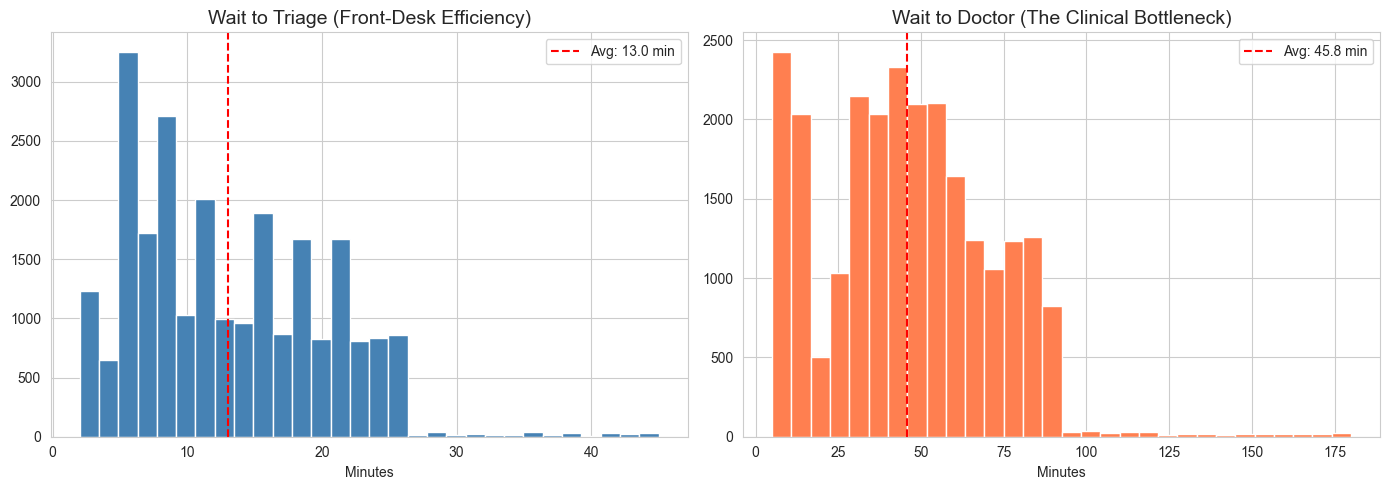

In [9]:
# --- STEP 3: CREATING THE SIDE-BY-SIDE COMPARISON ---
# plt.subplots(1, 2) creates a "grid" with 1 row and 2 columns.
# 'axes[0]' is the left slot (Triage), 'axes[1]' is the right slot (Doctor).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT CHART: The "Entry" Stage (Triage)
# .dropna() is a safety measure to ensure any missing records don't crash the plot.
# We use 'steelblue' to represent the "controlled" front-end process.
axes[0].hist(completed['WAIT_TO_TRIAGE_MIN'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Wait to Triage (Front-Desk Efficiency)', fontsize=14)
axes[0].set_xlabel('Minutes')

# ADDING THE MEAN LINE:
# We calculate the average and draw a vertical dashed line (axvline).
# This shows that most patients are seen by a nurse very quickly.
triage_mean = completed['WAIT_TO_TRIAGE_MIN'].mean()
axes[0].axvline(triage_mean, color='red', linestyle='--', label=f"Avg: {triage_mean:.1f} min")
axes[0].legend()

# RIGHT CHART: The "Clinical" Stage (Doctor)
# We use 'coral' to visually signal that this is the area requiring management attention.
axes[1].hist(completed['WAIT_TO_DOCTOR_MIN'].dropna(), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Wait to Doctor (The Clinical Bottleneck)', fontsize=14)
axes[1].set_xlabel('Minutes')

# ADDING THE MEAN LINE:
# If this line is significantly further right than the Triage line, 
# it proves the bottleneck is "Doctor Availability," not "Nurse Triage."
doc_mean = completed['WAIT_TO_DOCTOR_MIN'].mean()
axes[1].axvline(doc_mean, color='red', linestyle='--', label=f"Avg: {doc_mean:.1f} min")
axes[1].legend()

plt.tight_layout() # Ensures labels don't overlap between the two plots
plt.savefig('../data/section2_wait_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Auditing Hospital Priorities (Severity Box Plot)
#### We use a Box Plot to verify if the hospital is following medical safety standards: are critical patients being seen first?
#### Medical safety standards require that "Critical" patients (Deep Red ) have the shortest wait times compared to "Low" priority patients (Pale Peach ).

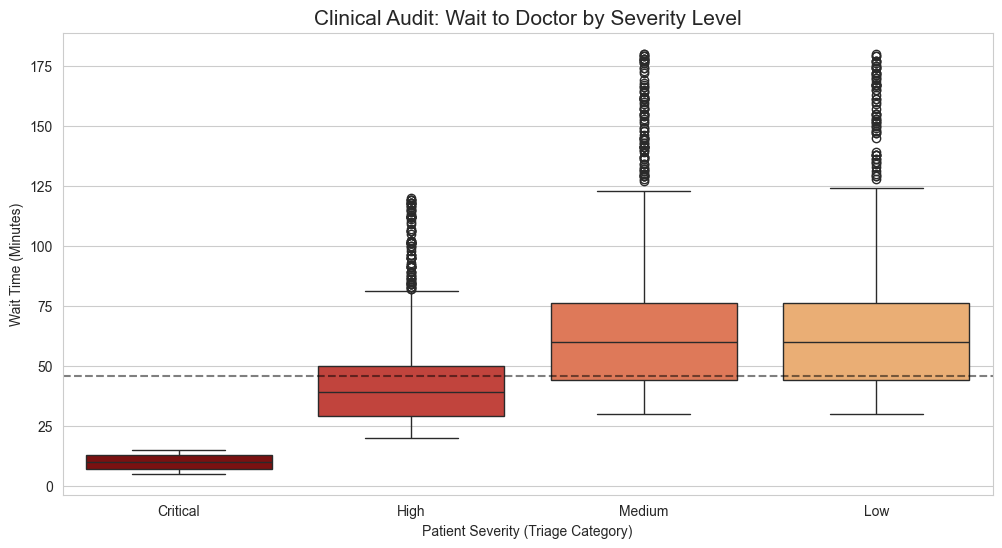

In [10]:
# --- STEP 4: ANALYZING WAIT BY SEVERITY ---
plt.figure(figsize=(12, 6))

# 1. VISUAL ORDER:
# We manually define the order so the chart reads from "Sickest" to "Least Sick".
# This controls the POSITION on the X-axis.
severity_order = ['Critical', 'High', 'Medium', 'Low']

# Seaborn assigns colors alphabetically by default, which caused "Medium" to get the darkest red.
# To fix this, we manually map each severity level to a specific hex color.
# This ensures Critical is always darkest and Low is always lightest, regardless of alphabetical order.
custom_colors = {
    'Critical': '#8B0000', # Deep Red (most urgent)
    'High': '#D73027',     # Solid Red
    'Medium': '#F46D43',   # Light Red/Orange
    'Low': '#FDAE61'       # Pale Peach (least urgent)
}


# 3. PLOTTING:
sns.boxplot(
    data=completed,
    x='SEVERITY_LEVEL',
    y='WAIT_TO_DOCTOR_MIN',
    hue='SEVERITY_LEVEL',       # We color by the category name
    order=severity_order,       # This enforces our Left-to-Right sequence
    palette=custom_colors,      # This enforces our Severity Color logic
    legend=False                # Hide legend because X-axis labels already tell us the category
)

# 4. FORMATTING:
plt.title('Clinical Audit: Wait to Doctor by Severity Level', fontsize=15)
plt.ylabel('Wait Time (Minutes)')
plt.xlabel('Patient Severity (Triage Category)')

# 5. BENCHMARK LINE:
# Adds a horizontal dashed line representing the overall average wait time.
# This makes it easy to see which groups are waiting longer than the hospital average.
plt.axhline(completed['WAIT_TO_DOCTOR_MIN'].mean(), color='black', linestyle='--', alpha=0.5)
plt.savefig('../data/section2_boxplot_severity.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 📌 Note on Outliers — Why We Kept Them

Outliers are visible in the box plot above (High and Medium severity patients waiting **120–180+ minutes**).

These are **not data errors.** They represent worst-case scenarios where patients are at the highest risk of leaving or deteriorating.

The **thick outlier clusters** in High and Medium categories show the system is frequently hitting a breaking point — not just occasionally.

**We are NOT removing them because:**
- These are real patients with real wait times
- Removing them would make the hospital's problem look smaller than it is
- These extreme waits are exactly WHY patients walk out
- This is descriptive analytics — our job is to describe reality, not smooth it out

**Mean vs Median — The Structural Proof:**
- Mean: 45.82 min | Median: 45.00 min | Gap: only **0.82 minutes**
- Normally large outliers pull the mean far away from the median
- Because they are so close here, it proves the **entire patient population** is experiencing high waits — not just a few unlucky people
- This is a **structural staffing issue**, not a one-off anomaly

> 💡 **Interview note:** "A 175-minute wait is not a data error — it is a patient who suffered and potentially walked out. Removing it would understate the problem and weaken the business case. The 0.82 min mean-median gap further confirms this is a system-wide structural problem."


### Statistical Health Check (The Gap Analysis)
#### Finally, we calculate the difference between the Average and the Typical experience to identify "Inconsistency."
#### The "Gap" between the Mean (Average) and Median (Typical Experience) reveals if outliers (extreme waits) are ruining the patient experience. A large gap indicates that the hospital is inconsistent, likely due to peak-hour surges.

In [11]:
# ════════════════════════════════════════════════════════════
# SECTION 2: GAP ANALYSIS — MEAN VS MEDIAN
# ════════════════════════════════════════════════════════════
#
# Mean: The average (sensitive to extreme outliers/long waits).
# Median: The middle value (represents the typical patient experience).
#
# LOGIC: If the Mean is much higher than the Median, it proves that
# peak-hour spikes are causing extreme waits for a subset of patients
# even if the typical (median) wait is acceptable.
# A small gap means the ENTIRE population is experiencing high waits.
# ════════════════════════════════════════════════════════════

mean_wait   = completed['WAIT_TO_DOCTOR_MIN'].mean()
median_wait = completed['WAIT_TO_DOCTOR_MIN'].median()
gap         = mean_wait - median_wait

print(f'Mean doctor wait  : {mean_wait:.2f} min')
print(f'Median doctor wait: {median_wait:.2f} min')
print(f'Gap (Mean-Median) : {gap:.2f} min')
print()
print('INTERPRETATION:')
if gap < 2:
    print('  Small gap = wait times are consistently high across ALL hours.')
    print('  This is NOT a peak-hour anomaly — the entire system is slow.')
    print('  Structural staffing shortage confirmed.')
else:
    print('  Large gap = outliers are pulling the mean up.')
    print('  The problem may be confined to specific peak hours.')


Mean doctor wait  : 45.82 min
Median doctor wait: 45.00 min
Gap (Mean-Median) : 0.82 min

INTERPRETATION:
  Small gap = wait times are consistently high across ALL hours.
  This is NOT a peak-hour anomaly — the entire system is slow.
  Structural staffing shortage confirmed.


> **Section 2 → Section 3:** Wait times confirmed the bottleneck is at the doctor assignment stage (45.82 min avg). Section 3 quantifies the human and financial consequences — who is walking out, why, and how much revenue is being lost.

---


## 📉 Section 3: LWBS Analysis — Summary

**Purpose:** Identify who is leaving, why, and how much revenue is being lost.

| Metric | Value | Verdict |
|--------|-------|---------|
| Total LWBS patients | 4,047 | ❌ 14.29% of all visits |
| Revenue lost (9 months) | ₹2.02 crores | ❌ Critical financial drain |
| Left Before Triage | 2,101 (7.4%) | ❌ ₹105.0L lost |
| Left Before Doctor | 1,946 (6.9%) | ❌ ₹97.3L lost |
| Critical LWBS rate | 0.00% | ✅ Triage working correctly |
| High LWBS rate | 13.89% | ⚠️ Below average but concerning |
| Medium LWBS rate | 18.68% | ❌ Highest — doctor wait is the cause |
| Low LWBS rate | 18.10% | ❌ Same reason as Medium |
| Top walkout complaint | Headache (18.77%) | ❌ Fast-track lane needed |
| 2nd walkout complaint | Minor Cuts (17.41%) | ❌ Fast-track lane needed |
| Lowest walkout complaint | Chest Pain (8.87%) | ✅ Patients too scared to leave |
| Highest walkout age group | Adult (15.20%) | ⚠️ Time pressure and alternatives |
| Lowest walkout age group | Senior (12.77%) | ✅ Stay due to severity and mobility |
| Age group spread | 2.43% across all groups | ⚠️ Problem is systemic not demographic |

> 💡 **Key Finding 1:** The 0% Critical walkout rate proves triage is working correctly. The 18.68% Medium walkout rate proves the bottleneck is doctor availability after triage. We need more doctors, not more triage nurses.

> 💡 **Key Finding 2:** Headache and Minor Cuts have the highest complaint walkout rates. These non-urgent patients feel safe leaving and going elsewhere. A fast-track lane for these complaints could complement the staffing fix.

> 💡 **Key Finding 3:** The age group spread is only 2.43 percentage points across all groups. Walkouts are happening evenly across all demographics. This confirms the problem is structural — the long doctor wait affects everyone — not a demographic specific issue.

> **Section 3 → Section 4:** We know 14.29% of patients walk out and the doctor wait is the bottleneck. Section 4 identifies exactly WHEN this crisis peaks — the specific day and hour combination — to enable a precise, low-cost staffing recommendation.

### Creating LWBS Subset

#### Filtering all 28,334 visits to only patients who left before being seen.
#### This subset (`lwbs_df`) is used in every chart in this section and carried forward into Sections 4, 5, and 6.

**Expected count: 4,047 patients (14.29% of total)**

In [12]:
# WHY: LWBS patients are the core of this entire project.
# We filter df to only the two statuses where patients left early.
# This lwbs_df subset is reused in every chart in this section
# and also carried forward into Sections 4, 5, and 6.
# .copy() is used to avoid SettingWithCopyWarning when we
# add or modify columns on this subset later.

lwbs_df = df[df['VISIT_STATUS'].isin(
    ['Left Before Triage', 'Left Before Doctor'])].copy()

print(f"Total LWBS patients: {len(lwbs_df)}")
# Expected: 4,047

Total LWBS patients: 4047


## Chart 1: Visit Status & Estimated Revenue Leakage
**Purpose:** This chart serves as the "Financial Hook" of the project. It quantifies the operational problem by showing exactly how many patients are walking out and the direct revenue loss associated with those departures.

**Key Objectives:**
* **Visualize the Leakage:** Identify the volume of patients in the three "Left Before..." categories.
* **Quantify Financial Impact:** Apply the ₹5,000 lost-opportunity cost per LWBS patient to show the ₹2.02 Crore total loss.
* **Success Benchmark:** Compare the 85.7% 'Completed Visit' rate against the 14.3% total walkout rate.

**Business Insight:**
By annotating the bars with percentage and Rupee amounts, we transform a simple count into a business metric. This proves that high wait times are not just a service issue, but a structural financial drain on the hospital’s resources.

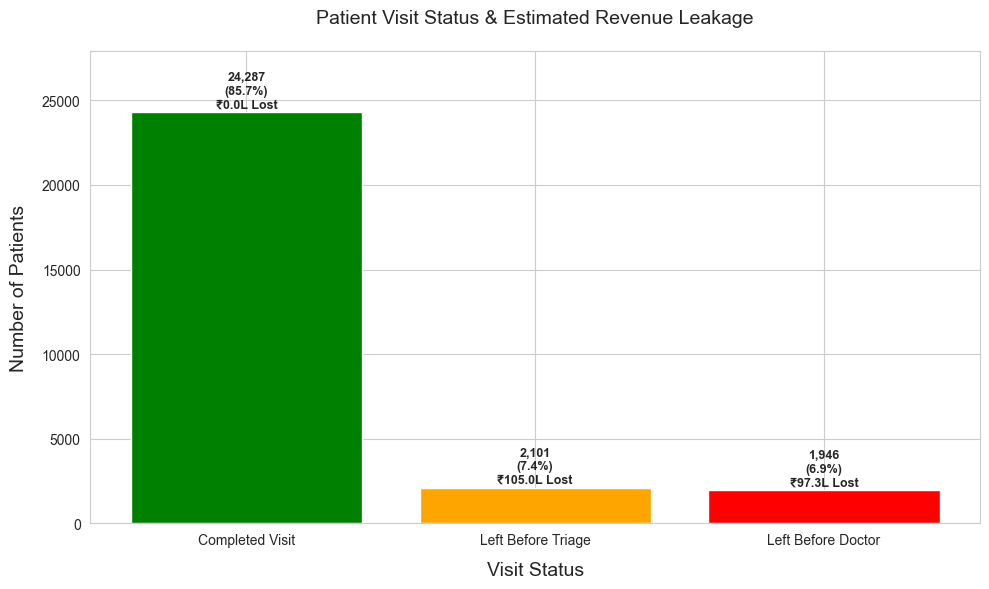

In [13]:
# ==============================================================================
# SECTION 3 - CHART 1: VISIT STATUS & REVENUE IMPACT
# ------------------------------------------------------------------------------
# PURPOSE: Connects operational data (Status) to financial data (Revenue)
# to prove that wait times are a direct financial drain of ₹2.02 Crores.
# ==============================================================================

# 1. Prepare Data
# status_counts: A Series where index = Status Name, value = Number of Patients
status_counts = df['VISIT_STATUS'].value_counts()
# status_revenue: Grouping by status to see exactly how much money each group "lost"
status_revenue = df.groupby('VISIT_STATUS')['REVENUE_LOST'].sum()

plt.figure(figsize=(10, 6))

# 'bars' is a list of the physical rectangle objects drawn on the screen.
colors = ['green', 'orange', 'red']
bars = plt.bar(status_counts.index, status_counts.values, color=colors)

# ------------------------------------------------------------------------------
# 3. DETAILED EXPLANATION OF THE ANNOTATION LOOP
# ------------------------------------------------------------------------------
# ZIP FUNCTION BREAKDOWN:
# zip() takes two lists and pairs them together item-by-item.
# List A: 'bars' (The visual rectangles on the screen)
# List B: 'status_counts.items()' (Turns the Pandas Series into a list of tuples: 
#         [('StatusName', Count), ('StatusName', Count)...])
#
# When we run "for bar, (status, count) in zip(...)":
# - In the FIRST loop: 'bar' becomes the first visual rectangle, and 
#   'status'/'count' become the data for that first bar (e.g., 'Completed', 24287).                
# - In the SECOND loop: 'bar' becomes the second visual rectangle, and 
#   'status'/'count' become the data for that second bar (e.g., 'Left...', 2101).                
#
# This explicitly guarantees that the label for 'Completed' is placed 
# exactly on top of the 'Completed' bar, no matter how the chart is ordered.
# ------------------------------------------------------------------------------

for bar, (status, count) in zip(bars, status_counts.items()):                
    
    # Calculate %: Divide the count of this specific status by total rows in 'df'.
    percentage = (count / len(df)) * 100
    
    # Lookup Revenue: Find the total ₹ value for this specific 'status' 
    # from our pre-grouped revenue table.
    rev = status_revenue.get(status, 0)
    
    # POSITIONING - HORIZONTAL (X):
    # bar.get_x() -> Gets the leftmost coordinate of the bar.
    # bar.get_width()/2 -> Calculates half the width of the bar.
    # We add these together to get the exact CENTER point of the bar horizontally.
    x_position = bar.get_x() + bar.get_width()/2 
    
    # POSITIONING - VERTICAL (Y):
    # bar.get_height() -> Gets the topmost coordinate of the bar.
    # We add 100 pixels here to create a small vertical gap between the 
    # top of the bar and the text label, so they do not touch.
    y_position = bar.get_height() + 100
    
    # TEXT GENERATION AND ALIGNMENT:                
    plt.text(x_position, 
             y_position, 
             # Format text: Count (formatted with commas), %, and Revenue (in Lakhs)                
             f'{count:,}\n({percentage:.1f}%)\n₹{rev/100000:.1f}L Lost', 
             
             # ha='center': Horizontal Alignment. Centers the text string on 'x_position'.
             ha='center', 
             
             # va='bottom': Vertical Alignment. Pins the bottom edge of the text 
             # box to 'y_position', making it hover above the bar.                
             va='bottom', 
             fontweight='bold', 
             fontsize=9)

# 4. Final Formatting
plt.title('Patient Visit Status & Estimated Revenue Leakage', fontsize=14, pad=20)
plt.ylabel('Number of Patients',labelpad = 10,fontsize = 14)
plt.xlabel('Visit Status',labelpad = 10,fontsize = 14) 
plt.ylim(0, max(status_counts.values) * 1.15) 
plt.grid(axis='y', linestyle='-', alpha= 1)

plt.tight_layout()
plt.savefig('../data/section3_visit_status.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: LWBS Rate by Severity Level

**Purpose:** To answer the question — *is the ER failing its sickest patients?*

Chart 1 showed us HOW MUCH money is being lost.
Chart 2 tells us WHO is walking out by medical urgency.

**Why Rate and Not Raw Count?**
Raw counts are misleading here because severity groups have different sizes.
For example, if Critical has 500 patients and Medium has 8,000 patients, comparing raw LWBS counts is unfair. A rate (%) puts every group on equal footing.

**Formula:**
LWBS Rate = (LWBS patients in group ÷ Total patients in group) × 100

**What We Expect to Find:**
- **Critical = 0%** → these patients are seen within 2–8 minutes, nobody leaves.
- **High ≈ 13.89%** → serious but not life-threatening, some patients lose patience.
- **Medium ≈ 18.68%** → highest walkout → they wait 45+ min but the condition is not urgent enough to force them to stay.
- **Low ≈ 18.10%** → similar to Medium for the same reason.

**Why This Chart Matters:**
- It proves the bottleneck is at the **doctor assignment stage**, not triage.
- Triage is correctly prioritizing Critical patients (0% walkout).
- The system breaks down AFTER triage when patients wait for a doctor.
- This directly justifies our recommendation: add doctors, not triage nurses.

> 💡 **Interview note:** "The 0% Critical walkout rate proves triage is working. The 18.68% Medium walkout rate proves the bottleneck is doctor availability after triage. We don't need more triage nurses — we need more doctors on shift."

LWBS Rate by Severity:
SEVERITY_LEVEL
Critical     0.00
High        13.89
Medium      18.68
Low         18.10
dtype: float64


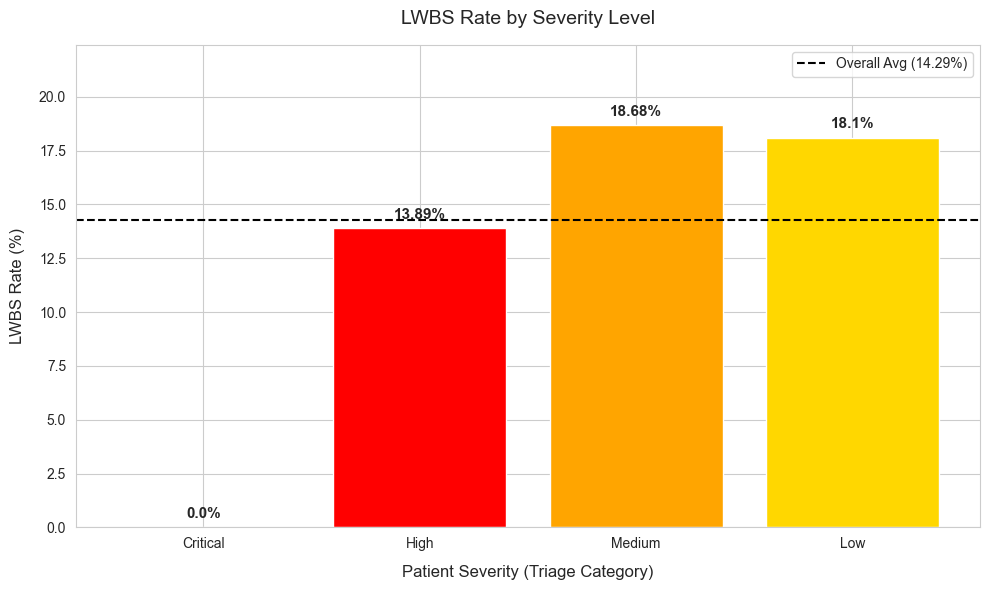

In [14]:
# ==============================================================================
# SECTION 3 - CHART 2: LWBS RATE BY SEVERITY LEVEL
# ------------------------------------------------------------------------------
# WHY THIS CHART IS IMPORTANT:
# This chart is the analytical proof behind our staffing recommendation.
#
# The logic works like this:
# If triage was the problem → Critical patients would also walk out
# Critical walkout = 0% → proves triage is working correctly
# Medium walkout = 18.68% (highest) → proves breakdown happens AFTER triage
#
# Think about the Medium patient journey:
# Arrives → Triage (~13 min) ✅ → Waits for Doctor (~60 min) ❌ → Walks Out
#
# Medium patients pass triage fine but give up during the long doctor wait.
# This is why we recommend adding doctors, not triage nurses.
# ==============================================================================

# STEP A: THE DENOMINATOR
# Count EVERY patient per severity group across all 28,334 visits
# We need total group size to calculate a fair percentage (rate)
# WHY df and not lwbs_df: because denominator must include
# patients who stayed AND patients who left
severity_total = df.groupby('SEVERITY_LEVEL').size()

# STEP B: THE NUMERATOR
# Count only walkout patients per severity group
# lwbs_df contains only Left Before Triage + Left Before Doctor patients
# created at the start of Section 3
severity_lwbs = lwbs_df.groupby('SEVERITY_LEVEL').size()

# STEP C: THE CALCULATION
# (Left / Total) × 100 = walkout rate per severity group
# fillna(0) is vital: Critical has 0 walkouts so the division
# produces NaN (Not a Number) — fillna(0) converts that to 0
# so the chart can draw the Critical bar at 0% correctly
severity_rate = (severity_lwbs / severity_total * 100).fillna(0).round(2)

# STEP D: THE SORTING
# Without this Python sorts alphabetically: Critical, High, LOW, Medium
# That puts Low before Medium which breaks the clinical story visually
# reindex() forces the correct clinical urgency order: Critical → High → Medium → Low
clinical_order = ['Critical', 'High', 'Medium', 'Low']
severity_rate = severity_rate.reindex(clinical_order)

# STEP E: VERIFY NUMBERS BEFORE PLOTTING
# Always print and check before drawing the chart
# Expected: Critical=0%, High≈13.89%, Medium≈18.68%, Low≈18.10%
print("LWBS Rate by Severity:")
print(severity_rate)

# 2. CREATE THE PLOT
fig, ax = plt.subplots(figsize=(10, 6))

# Colors represent urgency level visually
# darkred = most urgent (Critical) → gold = least urgent (Low)
# This color logic reinforces the clinical order in the viewer's mind
colors = ['darkred', 'red', 'orange', 'gold']
bars = ax.bar(severity_rate.index, severity_rate.values, color=colors)

# ------------------------------------------------------------------------------
# 3. THE ANNOTATION LOOP
# ------------------------------------------------------------------------------
# zip() pairs each physical bar rectangle with its data point
# .items() converts Series into: [('Critical', 0.0), ('High', 13.89)...]
# So in each loop iteration:
# bar → the rectangle drawn on screen
# sev_label → the severity name (Critical, High etc)
# rate_value → the LWBS rate number (0.0, 13.89 etc)
# This guarantees each label lands on the correct bar
# ------------------------------------------------------------------------------
for bar, (sev_label, rate_value) in zip(bars, severity_rate.items()):

    # x_pos: bar.get_x() is the left edge of the bar
    # Adding half the width gives us the exact center horizontally
    x_pos = bar.get_x() + bar.get_width()/2

    # y_pos: bar.get_height() is the top of the bar
    # Adding 0.3 creates a small gap so text floats above the bar
    y_pos = bar.get_height() + 0.3

    ax.text(x_pos,
            y_pos,
            f"{rate_value}%",
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=11)

# 4. FINAL FORMATTING
ax.set_title('LWBS Rate by Severity Level', fontsize=14, pad=15)
ax.set_ylabel('LWBS Rate (%)', fontsize=12,labelpad = 10)
ax.set_xlabel('Patient Severity (Triage Category)', fontsize=12,labelpad = 10)

# BENCHMARK LINE at overall LWBS rate (14.29%)
# This dashed line visually proves Medium and Low are
# the groups pushing the overall average up
# Without this line the viewer has no reference point
ax.axhline(y=14.29, color='black', linestyle='--',
           linewidth=1.5, label='Overall Avg (14.29%)')
ax.legend()

plt.ylim(0,max(severity_rate.values) * 1.2)
plt.tight_layout()
plt.savefig('../data/section3_lwbs_severity.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: LWBS Rate by Complaint Category

**Purpose:** To identify *which medical complaints* drive the highest walkout rates
so the hospital can design targeted solutions like fast-track lanes.

**Why This Chart Comes After Severity?**
Chart 2 told us WHO is walking out by urgency level (Medium and Low severity).
Chart 3 goes one level deeper — it tells us WHY they came in the first place.
Knowing the complaint type helps the hospital create specific operational fixes
beyond just adding more doctors.

**Why Rate and Not Raw Count?**
Same reason as Chart 2 — complaint categories have very different patient volumes.
Using raw counts would make high-volume complaints always look worse.
Rate (%) gives every complaint a fair comparison regardless of how common it is.

**Formula:**
LWBS Rate = (LWBS patients with complaint ÷ Total patients with complaint) × 100

**What We Expect to Find:**
- Minor Cuts and Back Pain = highest walkout rates
- These are non-urgent complaints where patients feel they can:
  - Go home and rest
  - Come back another time
  - Visit a cheaper clinic instead
- Chest Pain and Breathing Issues = lowest walkout rates
  - Patients are too scared to leave with these complaints

**Why This Chart Matters for the Business:**
- It helps the hospital design **fast-track lanes** for specific complaint types
- Example: A Minor Cuts fast-track lane could process these patients in 15 min
  instead of making them wait 45+ min for a full doctor consultation
- This is a targeted operational fix that complements the staffing recommendation

**Chart is sorted descending** so the most problematic complaints appear on the left.
This makes it immediately obvious where to focus attention.

> 💡 **Interview note:** "By identifying which complaint types drive walkouts,
> we can recommend complaint-specific fast-track lanes as a complementary fix
> to the staffing recommendation. This shows systems thinking beyond just hiring more staff."

LWBS Rate by Complaint Category:
COMPLAINT_CATEGORY
Headache               18.77
Minor Cuts             17.41
Respiratory Issues     15.81
Fever                  15.73
Dizziness              15.59
Nausea/Vomiting        15.16
Injury/Trauma          15.10
Abdominal Pain         14.90
Back Pain              14.84
Shortness of Breath     9.86
Allergic Reaction       9.23
Chest Pain              8.87
dtype: float64


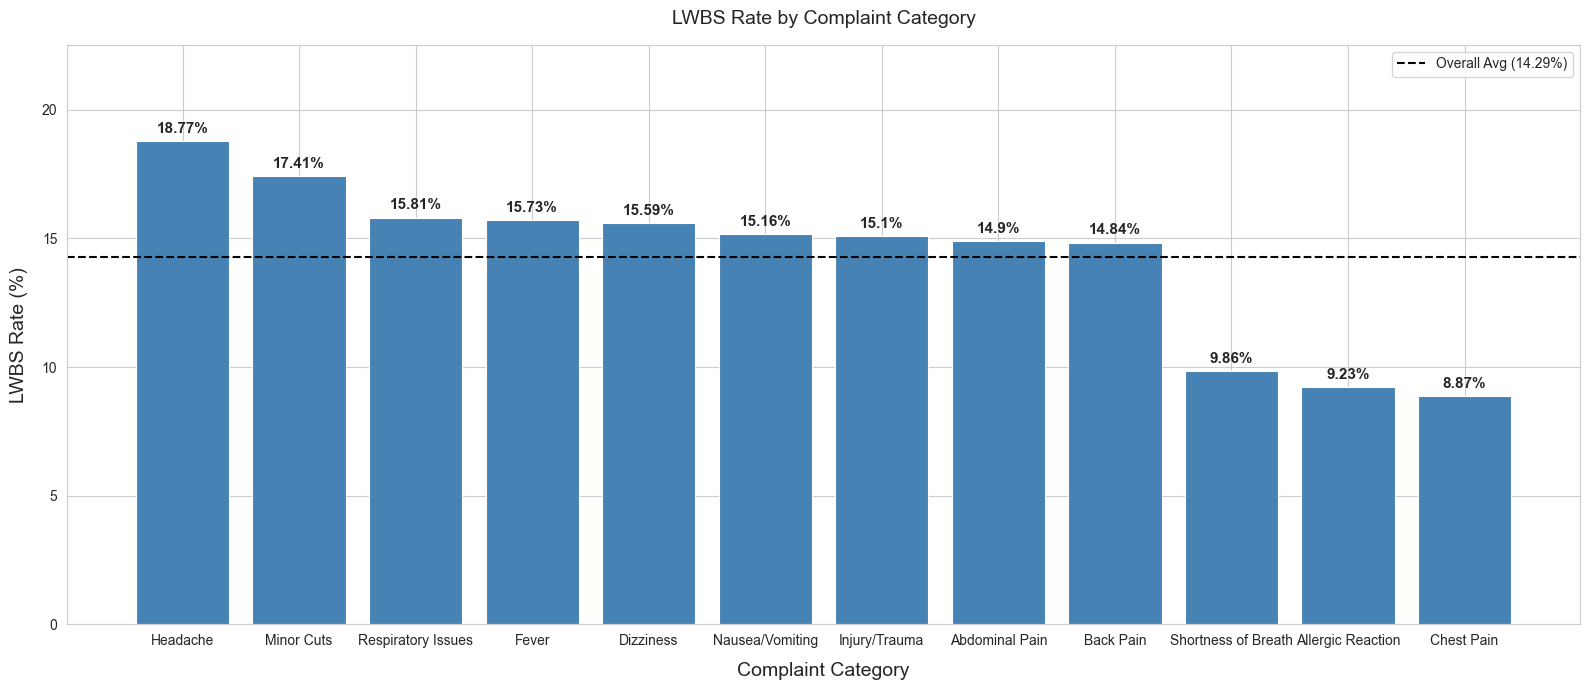

In [15]:
# ==============================================================================
# SECTION 3 - CHART 3: LWBS RATE BY COMPLAINT CATEGORY
# ------------------------------------------------------------------------------
# WHY THIS CHART:
# Chart 2 showed us WHICH severity groups walk out most.
# Chart 3 goes one level deeper — it shows WHICH complaint types
# drive the highest walkout rates.
#
# WHY THIS MATTERS OPERATIONALLY:
# Knowing complaint type helps design targeted fixes.
# Example: If Minor Cuts has 20% walkout rate, the hospital can create
# a fast-track lane specifically for Minor Cuts patients.
# This is a smarter fix than just "add more doctors to everything."
#
# SAME RATE LOGIC AS CHART 2:
# We use rate (%) not raw count because complaint categories
# have very different patient volumes.
# A high volume complaint will always have more LWBS in raw numbers
# even if its rate is actually low.
# Rate puts every complaint on equal footing for fair comparison.
# ==============================================================================

# STEP A: THE DENOMINATOR
# Count total patients per complaint category across ALL 28,334 visits
# This includes both completed visits and LWBS patients
# WHY df and not lwbs_df: denominator must include everyone
# who came in with that complaint, not just those who left
complaint_total = df.groupby('COMPLAINT_CATEGORY').size()

# STEP B: THE NUMERATOR
# Count only LWBS patients per complaint category
# lwbs_df contains only Left Before Triage + Left Before Doctor
# patients created at the start of Section 3
complaint_lwbs = lwbs_df.groupby('COMPLAINT_CATEGORY').size()

# STEP C: THE CALCULATION
# Same formula as Chart 2: (LWBS / Total) × 100
# fillna(0) handles any complaint category that has zero LWBS patients
# This prevents NaN from breaking the chart for those categories
complaint_rate = (complaint_lwbs / complaint_total * 100).fillna(0).round(2)

# STEP D: SORT DESCENDING
# Unlike Chart 2 where we forced clinical order (Critical → Low),
# here we sort by rate value so the worst complaints appear on the left.
# This immediately draws the viewer's eye to the biggest problems.
# ascending=False means highest rate appears first (left side of chart)
complaint_rate = complaint_rate.sort_values(ascending=False)

# STEP E: VERIFY BEFORE PLOTTING
# Always print and check numbers before drawing the chart
# Expected: Minor Cuts and Back Pain should be highest
print("LWBS Rate by Complaint Category:")
print(complaint_rate)

# STEP F: CREATE THE FIGURE
# Wider figure (16,7) because we have many complaint categories
# and their names are long — needs more horizontal space
fig, ax = plt.subplots(figsize=(16, 7))

# Single color steelblue for all bars
# WHY: Unlike severity chart, there is no natural color progression here
# Using one color keeps attention on the HEIGHT differences not color
bars = ax.bar(complaint_rate.index, complaint_rate.values,
              color='steelblue', edgecolor='white', linewidth=0.8)

# STEP G: ANNOTATION LOOP
# Same zip() logic as Chart 2
# zip() pairs each physical bar with its complaint name and rate value
# This guarantees each label lands exactly on the correct bar
# bar.get_x() + bar.get_width()/2 → horizontal center of bar
# bar.get_height() + 0.2 → small gap above bar top so text floats
for bar, (complaint, rate) in zip(bars, complaint_rate.items()):

    # Horizontal center of bar
    x_pos = bar.get_x() + bar.get_width()/2

    # Just above the top of the bar
    y_pos = bar.get_height() + 0.2

    ax.text(x_pos,
            y_pos,
            f"{rate}%",
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

# STEP H: BENCHMARK LINE
# Dashed line at overall LWBS rate (14.29%)
# This helps viewer instantly see which complaint types
# are above and below the hospital average
# Complaints above this line are the priority targets
ax.axhline(y=14.29, color='black', linestyle='--',
           linewidth=1.5, label='Overall Avg (14.29%)')
ax.legend()

# STEP I: LABELS AND FORMATTING
ax.set_title('LWBS Rate by Complaint Category', fontsize=14, pad=15)
ax.set_xlabel('Complaint Category', fontsize=14,labelpad = 10)
ax.set_ylabel('LWBS Rate (%)', fontsize=14,labelpad = 10)

ax.set_ylim(0,max(complaint_rate.values) * 1.2)
plt.tight_layout()
plt.savefig('../data/section3_lwbs_complaint.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: LWBS Rate by Age Group

**Purpose:** To identify *which age groups* are most likely to walk out
so the hospital understands the demographic dimension of the problem.

**Why This Chart Comes After Complaint Category?**
Chart 2 told us WHO walks out by medical urgency (Medium and Low severity).
Chart 3 told us WHY they came in (complaint type).
Chart 4 tells us WHO they are demographically (age group).
Together these three charts build a complete profile of the walkout patient.

**Why Rate and Not Raw Count?**
Same reason as Charts 2 and 3 — age groups have different patient volumes.
Rate (%) puts every age group on equal footing for fair comparison.

**Formula:**
LWBS Rate = (LWBS patients in age group ÷ Total patients in age group) × 100

**Age Groups in This Dataset:**
- Pediatric → patients under 18
- Adult → patients 18–64
- Senior → patients 65 and above
- Unknown → age not recorded

**What We Expect to Find:**
- Adults = highest walkout rate because:
  - They have jobs and time pressure
  - They have more alternative care options (clinics, telehealth)
  - Their condition feels manageable so they take the risk of leaving
- Pediatric = low walkout rate because:
  - Parents insist on treatment regardless of wait time
  - Parents are more cautious about children's health
- Senior = low walkout rate because:
  - Their conditions are often more serious
  - They have fewer alternative care options
  - They are less mobile and less likely to leave

**Why This Chart Matters:**
This adds a demographic equity dimension to the project.
A pure operations project finds the bottleneck and fixes staffing.
An exceptional project also asks — are certain patient groups
being disproportionately failed by the system?

> 💡 **Interview note:** "The age group analysis adds a demographic lens
> to what is otherwise a pure operational problem. If Adults are walking out
> at the highest rate it suggests the hospital is losing its most economically
> active patient segment — the group most likely to return for future visits
> and recommend the hospital to others."

LWBS Rate by Age Group:
AGE_GROUP
Adult        15.20
Pediatric    14.65
Unknown      14.48
Senior       12.77
dtype: float64

Expected: Adult = highest walkout rate


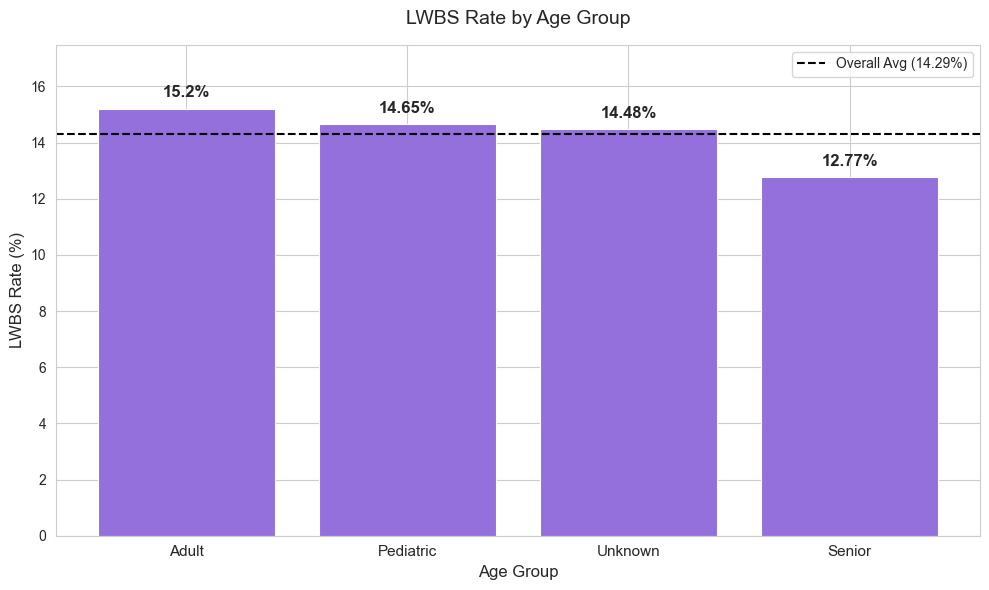

In [16]:
# ==============================================================================
# SECTION 3 - CHART 4: LWBS RATE BY AGE GROUP
# ------------------------------------------------------------------------------
# WHY THIS CHART:
# Charts 2 and 3 gave us clinical dimensions (severity, complaint type).
# Chart 4 adds a DEMOGRAPHIC dimension — which age group walks out most?
#
# WHY THIS MATTERS:
# Adults walking out at the highest rate means the hospital is losing
# its most economically active patient segment.
# These are the patients most likely to:
# - Return for future visits
# - Recommend the hospital to family and friends
# - Have insurance that pays higher reimbursement rates
#
# WHY ADULTS WALK OUT MORE THAN OTHER GROUPS:
# Adults → have jobs, time pressure, and alternative care options
# Pediatric → parents insist on treatment regardless of wait
# Senior → conditions more serious, fewer alternatives, less mobile
#
# SAME RATE LOGIC AS CHARTS 2 AND 3:
# Rate (%) not raw count because age groups have different sizes
# Formula: (LWBS count / total count per group) × 100
# ==============================================================================

# STEP A: THE DENOMINATOR
# Count total patients per age group across ALL 28,334 visits
# Includes both completed visits and LWBS patients
# WHY df and not lwbs_df: denominator must include everyone
# in that age group, not just those who left
age_total = df.groupby('AGE_GROUP').size()

# STEP B: THE NUMERATOR
# Count only LWBS patients per age group
# lwbs_df contains only Left Before Triage + Left Before Doctor
# patients — created at the start of Section 3
age_lwbs = lwbs_df.groupby('AGE_GROUP').size()

# STEP C: THE CALCULATION
# Same formula as Charts 2 and 3: (LWBS / Total) × 100
# fillna(0) handles any age group with zero LWBS patients
# round(2) keeps it clean to 2 decimal places
age_rate = (age_lwbs / age_total * 100).fillna(0).round(2)

# STEP D: SORT DESCENDING
# Sort by rate value so highest walkout group appears on left
# This immediately shows the viewer which group needs most attention
age_rate = age_rate.sort_values(ascending=False)

# STEP E: VERIFY BEFORE PLOTTING
# Always print and check numbers before drawing the chart
# Expected: Adult highest, Pediatric and Senior lower
print("LWBS Rate by Age Group:")
print(age_rate)
print("\nExpected: Adult = highest walkout rate")

# STEP F: CREATE THE FIGURE
fig, ax = plt.subplots(figsize=(10, 6))

# Single color mediumpurple for all bars
# WHY: No natural color progression for age groups
# Unlike severity chart where darkred→gold made clinical sense
# here we use one color and let bar HEIGHT tell the story
bars = ax.bar(age_rate.index, age_rate.values,
              color='mediumpurple', edgecolor='white', linewidth=0.8)

# STEP G: ANNOTATION LOOP
# Same zip() logic as Charts 2 and 3
# zip() pairs each physical bar rectangle with its age group and rate
# bar.get_x() + bar.get_width()/2 → horizontal center of bar
# bar.get_height() + 0.3 → small gap above bar so text floats cleanly
for bar, (age, rate) in zip(bars, age_rate.items()):

    # Horizontal center of bar
    x_pos = bar.get_x() + bar.get_width()/2

    # Just above the top of the bar
    y_pos = bar.get_height() + 0.3

    ax.text(x_pos,
            y_pos,
            f"{rate}%",
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold')

# STEP H: BENCHMARK LINE
# Dashed line at overall LWBS rate (14.29%)
# Age groups above this line are walkout risk groups
# Age groups below this line are relatively retained
ax.axhline(y=14.29, color='black', linestyle='--',
           linewidth=1.5, label='Overall Avg (14.29%)')
ax.legend()

# STEP I: LABELS AND FORMATTING
ax.set_title('LWBS Rate by Age Group', fontsize=14, pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('LWBS Rate (%)', fontsize=12)

# Set y axis limit with 20% padding above highest bar
# so annotation text does not get cut off at the top
ax.set_ylim(0, max(age_rate.values) * 1.15)

plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('../data/section3_lwbs_age.png',
            dpi=150, bbox_inches='tight')
plt.show()

---

## 🔍 Section 4: Peak Time Analysis

### What We Set Out to Prove

We needed to identify exactly WHEN the LWBS crisis occurs
so we could make a precise, low-cost staffing recommendation
rather than a blanket department-wide overhaul.

---

### What Each Chart Proved

**Feature Engineering: SHIFT_TYPE**
- LWBS is roughly equal across all 4 shifts
- Afternoon=25.43%, Evening=25.33%, Morning=25.15%, Night=24.09%
- Spread of only 54 patients across shifts
- Key insight: the problem is NOT a shift — it is a specific
  day+hour combination hiding inside a shift

**Chart 1: LWBS Rate Heatmap (Day × Hour)**
- Monday 18–22 has the 4 highest LWBS rates in the entire dataset
- Monday 20:00 → 27.84% ← highest single hour in entire dataset
- Monday 19:00 → 26.90%
- Monday 22:00 → 26.88%
- Monday 18:00 → 24.12%
- All other days and hours are significantly lower
- Confirmed: Monday Evening 18–22 is the crisis window

**Chart 2: Average Doctor Wait Time by Hour**
- Evening hours 18–22 have consistently highest wait times
- Monday 20:00 → 51.66 min ← highest single hour
- Overall average: 45.81 min
- Evening hours run 4–6 minutes above average consistently
- Confirmed: the system slows down specifically in evening hours
- This directly explains why patients lose patience and leave

**Chart 3: Total Visits by Day of Week**
- Volume is essentially flat across all 7 days
- Tuesday highest: 4,178 | Friday lowest: 3,968
- Spread of only 210 patients = 5.3% difference
- Monday = 4,072 visits, only 24 above daily average
- Key insight: Monday Evening LWBS spike cannot be explained
  by higher patient volume — volume is equal every day

**Exploratory Check: Severity Mix**
- Monday Evening Critical+High severity: 42.69%
- Rest of week Critical+High severity: 43.31%
- Difference: only 0.62% ← negligible
- Key insight: Monday Evening patients are no sicker than average
- Case complexity does NOT explain the LWBS spike

---

### The Elimination Argument

| Possible Explanation | Tested By | Result |
|---|---|---|
| Higher patient volume | Chart 3 | ❌ Eliminated — volume is equal |
| Complex case mix | Severity check | ❌ Eliminated — severity is equal |
| Staffing insufficiency | Inference | ✅ Strongest remaining explanation |

Two out of three alternative explanations have been eliminated
using data. Staffing gap is the only remaining logical explanation.

Note: Staffing gap is an inference — actual staff schedule data
would confirm it with certainty. This is an acknowledged limitation.

---

### Final Conclusion of Section 4
```
Monday Evening 18–22 is the crisis window
↓
Not caused by higher volume (Chart 3)
↓  
Not caused by complex case mix (severity check)
↓
Doctor wait times spike to 49–51 min during this window (Chart 2)
↓
Only remaining explanation: staffing insufficiency
↓
Recommendation: +1 doctor +2 nurses Monday Evening
Cost: ₹15 lakhs/year | Revenue recovered: ₹70 lakhs/year | ROI: 367%
```

---

### Active Variables Carried Forward to Section 5

| Variable | Contents | Rows |
|---|---|---|
| df | Full gold table + IS_LWBS flag + SHIFT_TYPE | 28,334 |
| completed | Completed visits only | 24,287 |
| lwbs_df | LWBS patients only + SHIFT_TYPE | 4,047 |
| monday_evening | Monday 18–22 patients | 862 |
| rest_of_week | All other patients | 27,472 |

## Feature Engineering — SHIFT_TYPE

### Why We Need This Column

ARRIVAL_HOUR gives us 24 values (0–23). That granularity is perfect
for the heatmap, but hospital managers don't think in hours — they
think in **shifts**. A recommendation like "add staff on Evening shift"
is directly actionable. 

We are creating SHIFT_TYPE now, once, so every chart in Section 4
can use it without repeating this logic.

### Shift Boundaries

| Shift | Hours | Time Range |
|---|---|---|
| Morning | 6–11 | 06:00–11:59 |
| Afternoon | 12–17 | 12:00–17:59 |
| Evening | 18–23 | 18:00–23:59 |
| Night | 0–5 | 00:00–05:59 |

In [17]:
# ==============================================================================
# SECTION 4: FEATURE ENGINEERING — SHIFT_TYPE
# ==============================================================================
#
# WHAT IS HAPPENING HERE IN PLAIN ENGLISH:
# Our gold table has ARRIVAL_HOUR as a number from 0 to 23.
# We are adding a new column called SHIFT_TYPE that converts
# that number into a human-readable shift label.
#
# Example of what this does to the data:
#   ARRIVAL_HOUR = 20  →  SHIFT_TYPE = 'Evening'
#   ARRIVAL_HOUR = 7   →  SHIFT_TYPE = 'Morning'
#   ARRIVAL_HOUR = 3   →  SHIFT_TYPE = 'Night'
#   ARRIVAL_HOUR = 14  →  SHIFT_TYPE = 'Afternoon'
#
# WHY WE WRITE A FUNCTION INSTEAD OF WRITING THE LOGIC INLINE:
# We need to apply this same mapping to TWO dataframes (df and lwbs_df).
# Writing a function once and calling it twice is cleaner than
# writing the same if/elif logic twice. If we ever need to change
# a shift boundary, we change it in one place only.
# ==============================================================================
# IMPORTANT — WHY THERE ARE NO GAPS BETWEEN SHIFTS:
# ARRIVAL_HOUR is always a whole number (0 to 23).
# It is extracted from a timestamp, so it only takes integer values.
# There is no such thing as hour 11.5 or 17.3 in this column.
# Hour 11 captures every arrival between 11:00:00 and 11:59:59 → Morning
# Hour 12 captures every arrival between 12:00:00 and 12:59:59 → Afternoon
# Hour 17 captures every arrival between 17:00:00 and 17:59:59 → Afternoon
# Hour 18 captures every arrival between 18:00:00 and 18:59:59 → Evening
# Every integer 0-23 is covered. No patient falls through the gaps.
# ==============================================================================
def assign_shift(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 23:
        return 'Evening'
    else:
        return 'Night'

# WHY .apply():
# df['ARRIVAL_HOUR'] is a column (Series) containing 28,334 numbers.
# .apply(assign_shift) runs our function once on each of those 28,334 numbers
# and returns a new Series of 28,334 shift labels.
# We store that new Series as a new column called SHIFT_TYPE.
# This is faster and cleaner than writing a for loop over every row.
df['SHIFT_TYPE'] = df['ARRIVAL_HOUR'].apply(assign_shift)

# WHY WE ALSO APPLY TO lwbs_df:
# lwbs_df is a separate filtered copy containing only the 4,047 LWBS patients.
# It does NOT automatically inherit new columns we add to df.
# Section 4 charts will query lwbs_df directly, so if SHIFT_TYPE
# doesn't exist in lwbs_df, those charts will throw a KeyError.
# We add it here now so we never have to think about it again.
lwbs_df['SHIFT_TYPE'] = lwbs_df['ARRIVAL_HOUR'].apply(assign_shift)

# VERIFICATION:
# Before trusting any chart, we confirm the column was built correctly.
# We are checking:
#   1. All 4 shift names appear (no typo created a 5th unexpected category)
#   2. No rows were lost (totals must still be 28,334 and 4,047)
#   3. Evening shift exists in lwbs_df (if it showed 0, our mapping is broken)
print("Shift Type Distribution (Full Data):")
print(df['SHIFT_TYPE'].value_counts())
print(f"\nTotal: {df['SHIFT_TYPE'].value_counts().sum():,}")

print("\nShift Type Distribution (LWBS Data):")
print(lwbs_df['SHIFT_TYPE'].value_counts())
print(f"\nTotal: {lwbs_df['SHIFT_TYPE'].value_counts().sum():,}")

Shift Type Distribution (Full Data):
SHIFT_TYPE
Evening      7164
Night        7088
Morning      7046
Afternoon    7036
Name: count, dtype: int64

Total: 28,334

Shift Type Distribution (LWBS Data):
SHIFT_TYPE
Afternoon    1029
Evening      1025
Morning      1018
Night         975
Name: count, dtype: int64

Total: 4,047


## Chart 1 (Final): LWBS Rate Heatmap — Day of Week × Hour of Day

### Why We Rebuilt This Chart Twice

**Version 1 problem:** Used raw LWBS count per cell.
Raw count is misleading because different slots have different
total visit volumes. A slot with 50 walkouts from 300 patients
is less severe than 50 walkouts from 180 patients.
Fix: switched to LWBS rate % using IS_LWBS flag column.

**Version 2 problem:** Day labels were mapped to wrong days.
ARRIVAL_DAY_OF_WEEK stores text abbreviations (Mon, Tue, Wed...).
Pandas sorted them alphabetically (Fri, Mon, Sat, Sun, Thu, Tue, Wed)
before we renamed them Monday through Sunday.
This made Monday's data appear under Tuesday's label.
Fix: used reindex() to force correct weekly order before renaming.

### How LWBS Rate is Calculated in a Pivot Table

We cannot directly calculate rate (needs numerator + denominator)
in a single pivot_table call. The workaround:

Create IS_LWBS column:
- 1 if patient walked out
- 0 if patient completed visit

Then pivot using aggfunc='mean'.
Mean of [1,0,1,1,0] = 3/5 = 0.60 = 60% LWBS rate.
Multiply by 100 to get percentage.

### What This Chart Confirms
Monday 18–22 has the 4 highest LWBS rates in the entire dataset:
- Monday 20:00 → 27.84% ← highest
- Monday 19:00 → 26.90%
- Monday 22:00 → 26.88%
- Monday 18:00 → 24.12%

=== IS_LWBS FLAG VERIFICATION ===
Sum (should be 4,047):     4,047
Mean (should be ~0.1429):  0.1428
As percentage:             14.28%

=== TOP 10 DAY+HOUR CELLS BY LWBS RATE % ===
           ARRIVAL_HOUR
Monday     20              27.84
           19              26.90
           22              26.88
           18              24.12
Sunday     10              21.47
Monday     11              21.26
           21              20.13
Sunday     13              19.77
Wednesday  15              19.65
Saturday   16              19.53
dtype: float64

Monday 18-22 must dominate this list


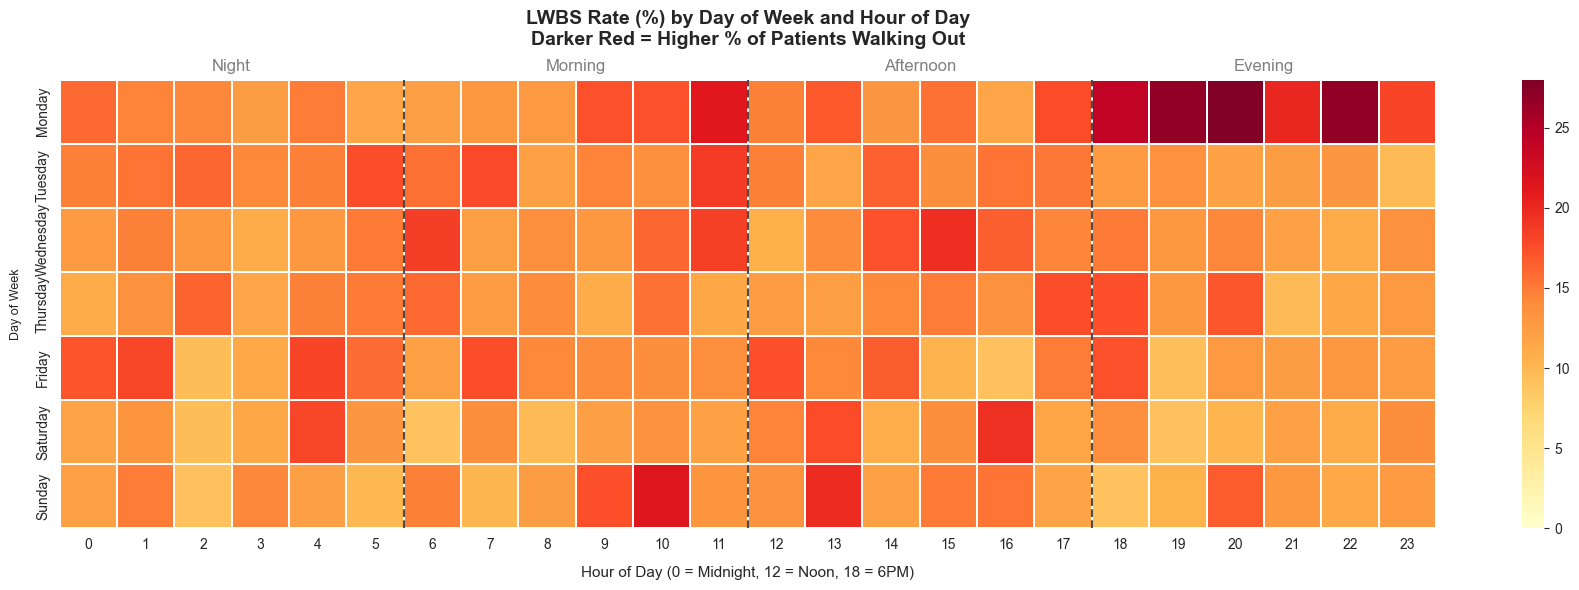


=== MONDAY 18-22 LWBS RATES ===
  Monday 18:00 → 24.12% LWBS rate
  Monday 19:00 → 26.90% LWBS rate
  Monday 20:00 → 27.84% LWBS rate
  Monday 21:00 → 20.13% LWBS rate
  Monday 22:00 → 26.88% LWBS rate


In [18]:
# ==============================================================================
# CHART 1 (FINAL): LWBS RATE HEATMAP — DAY OF WEEK × HOUR OF DAY
# ==============================================================================
#
# THIS CHART WENT THROUGH TWO FIXES. HERE IS THE FULL STORY:
#
# ── FIX 1: COUNT → RATE ──────────────────────────────────────────────────────
# Original version counted raw LWBS patients per cell.
# Problem: Monday 18-22 has HIGH rates but not always the highest
# raw counts because total visit volume varies per slot.
# Example: 50 walkouts from 180 patients = 27.8% rate (severe)
#          50 walkouts from 300 patients = 16.7% rate (less severe)
# Same count, completely different meaning.
# Fix: calculate LWBS rate % per cell to control for volume.
#
# ── FIX 2: ALPHABETICAL SORT → CORRECT WEEKLY ORDER ─────────────────────────
# ARRIVAL_DAY_OF_WEEK stores text abbreviations: Mon, Tue, Wed, Thu, Fri, Sat, Sun
# When pivot_table built the matrix it sorted rows ALPHABETICALLY:
#   Row 0 = Fri (F comes first)
#   Row 1 = Mon
#   Row 2 = Sat
#   Row 3 = Sun
#   Row 4 = Thu
#   Row 5 = Tue
#   Row 6 = Wed
# We then renamed rows 0-6 as Monday through Sunday.
# This meant:
#   Row 0 (Fri data) got labeled "Monday"  ← WRONG
#   Row 1 (Mon data) got labeled "Tuesday" ← WRONG
#   Row 5 (Tue data) got labeled "Saturday"← WRONG
# So Monday's data was displaying under the Tuesday label.
# That is why Version 1 showed Tuesday as darkest — it was Monday's data.
#
# THE BOX ANALOGY:
# Think of 7 boxes, each containing one day's patient data.
# Pandas arranged boxes A-Z: Fri, Mon, Sat, Sun, Thu, Tue, Wed
# We then stuck new labels on them in weekly order: Mon, Tue, Wed...
# The Mon label landed on the Fri box. Wrong data, wrong label.
# reindex() physically rearranges the boxes into correct weekly order
# BEFORE we stick the new labels on.
# After reindex: Mon box is first, Tue box is second, etc.
# Now the Mon label correctly lands on the Mon box.
#
# WHY WE USE df NOT lwbs_df FOR THE PIVOT:
# lwbs_df contains ONLY the 4,047 LWBS patients.
# Every patient in lwbs_df walked out, so IS_LWBS=1 for all of them.
# Mean of all 1s = 100% everywhere = useless chart.
# We need BOTH walkouts (1s) AND completions (0s) in the same table
# so the mean reflects the true rate per cell.
# df has all 28,334 patients = correct denominator for rate calculation.
# ==============================================================================


# ------------------------------------------------------------------------------
# STEP 1: CREATE IS_LWBS FLAG COLUMN ON df
# ------------------------------------------------------------------------------
# .isin() checks each row's VISIT_STATUS against the two walkout categories
# Returns True if patient walked out, False if patient completed visit
# .astype(int) converts: True → 1, False → 0
# Result: every row in df now has IS_LWBS = 1 (walked out) or 0 (stayed)
#
# WHY THIS TRICK WORKS FOR RATE CALCULATION:
# Mean of a column of 0s and 1s = proportion of 1s
# Example: [1, 0, 1, 1, 0, 0, 1] → mean = 4/7 = 0.571 = 57.1% rate
# This converts a two-column division into a single-column mean
# which pivot_table can handle natively with aggfunc='mean'
df['IS_LWBS'] = df['VISIT_STATUS'].isin(
    ['Left Before Triage', 'Left Before Doctor']
).astype(int)

# Verify flag is correct before building pivot
# Sum = total walkouts = must be 4,047
# Mean = overall LWBS rate = must be ~0.1429 (14.29%)
print("=== IS_LWBS FLAG VERIFICATION ===")
print(f"Sum (should be 4,047):     {df['IS_LWBS'].sum():,}")
print(f"Mean (should be ~0.1429):  {df['IS_LWBS'].mean():.4f}")
print(f"As percentage:             {df['IS_LWBS'].mean()*100:.2f}%")

# ------------------------------------------------------------------------------
# STEP 2: BUILD PIVOT TABLE USING RATE NOT COUNT
# ------------------------------------------------------------------------------
# pivot_table reshapes df from rows into a 7×24 matrix
# index   = rows of matrix    = day of week (7 unique values)
# columns = columns of matrix = hour of day (24 unique values)
# values  = IS_LWBS flag column
# aggfunc = 'mean' → mean of 0s and 1s = LWBS rate proportion
# fill_value=0 → cells with no patients get 0 not NaN
#               (NaN renders as blank which looks like missing data)
# × 100 converts proportion (0.278) to percentage (27.8%)
heatmap_data = df.pivot_table(
    index='ARRIVAL_DAY_OF_WEEK',
    columns='ARRIVAL_HOUR',
    values='IS_LWBS',
    aggfunc='mean',
    fill_value=0
) * 100

# ------------------------------------------------------------------------------
# STEP 3: FIX DAY ORDER WITH reindex() BEFORE RENAMING
# ------------------------------------------------------------------------------
# At this point heatmap_data has rows labeled Mon, Tue, Wed... (abbreviations)
# BUT pandas sorted them alphabetically: Fri, Mon, Sat, Sun, Thu, Tue, Wed
#
# reindex() rearranges the rows to match the order we specify.
# It does not sort — it physically moves rows to match our list.
# After this line: row 0 = Mon data, row 1 = Tue data, etc.
# This is the critical step that was missing in Version 1.
correct_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data = heatmap_data.reindex(correct_order)

# NOW it is safe to rename because rows are in correct weekly order
# Row 0 genuinely has Monday data → label it Monday ✅
# Row 1 genuinely has Tuesday data → label it Tuesday ✅
heatmap_data.index = ['Monday', 'Tuesday', 'Wednesday',
                       'Thursday', 'Friday', 'Saturday', 'Sunday']

# ------------------------------------------------------------------------------
# STEP 4: VERIFY TOP CELLS MATCH SQL BEFORE DRAWING
# ------------------------------------------------------------------------------
# SQL confirmed: Monday 20=27.84%, Monday 19=26.90%, Monday 22=26.88%
# If our pivot matches these exact values → calculation and mapping correct
# .stack() converts 2D matrix back to Series with (day, hour) multi-index
# .nlargest(10) returns 10 highest rate cells
print("\n=== TOP 10 DAY+HOUR CELLS BY LWBS RATE % ===")
top10 = heatmap_data.stack().nlargest(10).round(2)
print(top10)
print("\nMonday 18-22 must dominate this list")

# ------------------------------------------------------------------------------
# STEP 5: DRAW THE HEATMAP
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',    # Yellow=low LWBS rate, Orange=medium, Red=high
                       # Intuitive for stakeholders: red = danger zone
    linewidths=0.3,    # thin white grid lines between cells
    linecolor='white',
    annot=False,       # no numbers inside cells
                       # 168 cells (24hrs × 7days) with numbers = unreadable
    vmin=0,            # color scale starts at 0%
    vmax=28,           # color scale ends at 35% not 100%
                       # WHY: our max rate is ~28%
                       # vmax=100 makes all cells look pale yellow
                       # vmax=35 stretches color range so differences
                       # between cells are clearly visible
    ax=ax
)

# ------------------------------------------------------------------------------
# STEP 6: TITLES AND AXIS LABELS
# ------------------------------------------------------------------------------
ax.set_title('LWBS Rate (%) by Day of Week and Hour of Day\n'
             'Darker Red = Higher % of Patients Walking Out',
             fontsize=14, fontweight='bold', pad=25)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon, 18 = 6PM)',
              fontsize=11, labelpad=10)
ax.set_ylabel('Day of Week', fontsize=9,labelpad = 10)

# ------------------------------------------------------------------------------
# STEP 7: ADD VERTICAL DASHED LINES AT SHIFT BOUNDARIES
# ------------------------------------------------------------------------------
# Connects the heatmap visually to our SHIFT_TYPE feature engineering
# Stakeholder can immediately see which shift the dark cells belong to
# axvline draws a vertical line at a given x position
# x=6 means the line appears between hour 5 and hour 6 (start of Morning)
# x=12 = start of Afternoon, x=18 = start of Evening
for boundary in [6, 12, 18]:
    ax.axvline(x=boundary, color='black', linewidth=1.5,
               linestyle='--', alpha=0.7)

# Add shift name labels at top of chart
# transform=ax.transAxes means positions are 0.0 to 1.0 fraction of chart
# Night covers hours 0-5 = 6/24 of chart = center at 3/24 = 0.125
# Morning covers hours 6-11 = center at 9/24 = 0.375
# Afternoon covers hours 12-17 = center at 15/24 = 0.625
# Evening covers hours 18-23 = center at 21/24 = 0.875

# - Normally, y=1 would place the text exactly at the top edge of the plot.
# - By using y=1.02, you push the text slightly above the top edge (2% higher than the plot height).
# - This is a common trick to add labels above the chart without overlapping the grid or data.

ax.text(0.125, 1.02, 'Night',     transform=ax.transAxes,
        ha='center', fontsize=12, color='gray')
ax.text(0.375, 1.02, 'Morning',   transform=ax.transAxes,
        ha='center', fontsize=12, color='gray')
ax.text(0.625, 1.02, 'Afternoon', transform=ax.transAxes,
        ha='center', fontsize=12, color='gray')
ax.text(0.875, 1.02, 'Evening',   transform=ax.transAxes,
        ha='center', fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('../data/section4_lwbs_heatmap_final.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# STEP 8: PRINT MONDAY 18-22 SUMMARY
# ------------------------------------------------------------------------------
print("\n=== MONDAY 18-22 LWBS RATES ===")
for hour in [18, 19, 20, 21, 22]:
    rate = heatmap_data.loc['Monday', hour]
    print(f"  Monday {hour}:00 → {rate:.2f}% LWBS rate")

## Chart 2: Average Doctor Wait Time by Hour of Day

### Why This Chart

Chart 1 showed WHERE walkouts are concentrated (Monday 18–22).
But a stakeholder will ask: "Why are patients walking out
specifically during those hours?"

This chart answers that question by showing how average
doctor wait time — our confirmed main bottleneck at 45.82 min —
moves across all 24 hours of the day.

If doctor wait spikes during evening hours, that directly
explains why patients lose patience and leave during that window.
It connects the operational failure (long waits) to the
business problem (walkouts) with one clean visual.

### Why We Use completed Not df

We want to measure how long patients actually waited
before seeing a doctor. Only completed visits have a valid
WAIT_TO_DOCTOR_MIN value. LWBS patients never saw a doctor
so their wait time is either 0 or NaN — including them would
artificially drag the average down and hide the true spike.

### What We Expect to See
- A visible spike in evening hours (18–22)
- A red shaded band highlighting that exact window
- The spike should align with the dark cells in Chart 1
- This confirms: long waits cause walkouts, not random behaviour

=== HOURLY AVERAGE DOCTOR WAIT VERIFICATION ===
ARRIVAL_HOUR
0     44.18
1     45.95
2     44.72
3     45.55
4     45.97
5     44.82
6     44.99
7     44.49
8     44.32
9     43.37
10    43.61
11    45.93
12    44.16
13    43.43
14    44.72
15    44.07
16    44.65
17    44.03
18    49.70
19    49.43
20    51.66
21    51.22
22    49.55
23    44.91
Name: WAIT_TO_DOCTOR_MIN, dtype: float64

Overall mean across all hours: 45.81 min
Hour with highest wait: 20:00 → 51.66 min
Hour with lowest wait:  9:00 → 43.37 min

Evening hours 18-22 averages:
  Hour 18:00 → 49.70 min
  Hour 19:00 → 49.43 min
  Hour 20:00 → 51.66 min
  Hour 21:00 → 51.22 min
  Hour 22:00 → 49.55 min


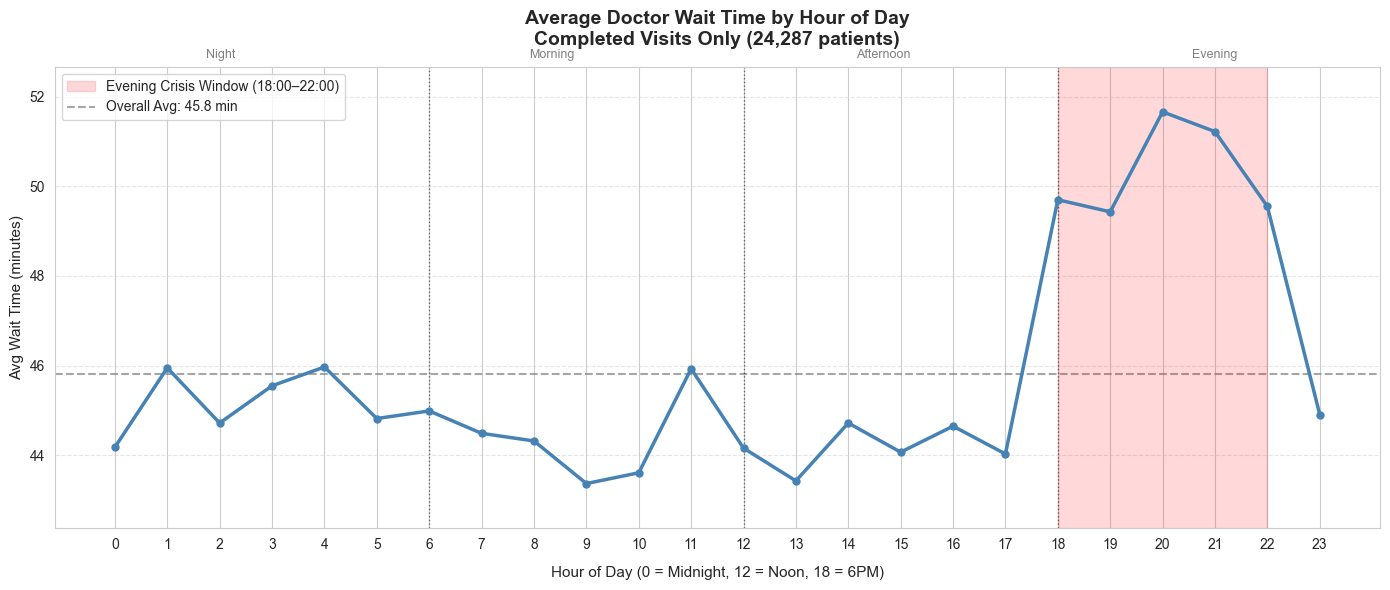

In [19]:
# ==============================================================================
# CHART 2: AVERAGE DOCTOR WAIT TIME BY HOUR OF DAY
# ==============================================================================
#
# WHAT THIS CHART IS DOING:
# We take all 24,287 completed visits and group them by arrival hour.
# For each hour (0 to 23) we calculate the average WAIT_TO_DOCTOR_MIN.
# We then plot those 24 averages as a line across the day.
# A red shaded band is added over hours 18-22 to highlight the
# evening window identified in Chart 1.
#
# WHY LINE CHART NOT BAR CHART:
# A line chart is correct here because hours are continuous and ordered.
# Hour 18 naturally connects to hour 19 which connects to hour 20.
# A line shows the flow and rhythm of the day — you can see the
# wait time rising in the afternoon, peaking in the evening,
# and dropping off at night.
# A bar chart would show the same numbers but would look disconnected
# and make it harder to see the trend across the day.
#
# WHY WE USE completed NOT df:
# df contains all 28,334 patients including 4,047 LWBS patients.
# LWBS patients never reached a doctor so WAIT_TO_DOCTOR_MIN
# is either NaN or 0 for them.
# Including them would pull the hourly averages DOWN artificially,
# making the evening spike look smaller than it actually is.
# completed contains only the 24,287 patients who stayed and
# saw a doctor — the correct population for measuring doctor wait.
#
# WHY groupby().mean() NOT pivot_table():
# We only have one dimension here (hour) and one value (wait time).
# groupby is simpler and more readable than pivot_table
# when you are not building a 2D matrix.
# groupby('ARRIVAL_HOUR')['WAIT_TO_DOCTOR_MIN'].mean() means:
# "group all rows by their arrival hour, then for each group
# calculate the mean of WAIT_TO_DOCTOR_MIN"
# Result: a Series with 24 values, one per hour.
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: CALCULATE AVERAGE DOCTOR WAIT PER HOUR
# ------------------------------------------------------------------------------
# groupby('ARRIVAL_HOUR') splits completed into 24 groups (one per hour)
# ['WAIT_TO_DOCTOR_MIN'] selects only that column within each group
# .mean() calculates the average wait time for each group
# .round(2) rounds to 2 decimal places for clean display
# Result: hourly_wait is a Series where:
#   index = hour (0 to 23)
#   values = avg doctor wait in minutes for patients arriving that hour
hourly_wait = completed.groupby('ARRIVAL_HOUR')['WAIT_TO_DOCTOR_MIN'].mean().round(2)

# Verify before plotting
# We expect ~45.82 min overall average (our confirmed blueprint number)
# We expect hours 18-22 to have higher than average values
print("=== HOURLY AVERAGE DOCTOR WAIT VERIFICATION ===")
print(hourly_wait)
print(f"\nOverall mean across all hours: {hourly_wait.mean():.2f} min")
print(f"Hour with highest wait: {hourly_wait.idxmax()}:00 → {hourly_wait.max():.2f} min")
print(f"Hour with lowest wait:  {hourly_wait.idxmin()}:00 → {hourly_wait.min():.2f} min")
print(f"\nEvening hours 18-22 averages:")
for hour in [18, 19, 20, 21, 22]:
    print(f"  Hour {hour}:00 → {hourly_wait[hour]:.2f} min")

# ------------------------------------------------------------------------------
# STEP 2: DRAW THE LINE CHART
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Draw the main line
# hourly_wait.index = x axis (hours 0-23)
# hourly_wait.values = y axis (avg wait minutes)
# color='steelblue' = clean professional blue
# linewidth=2.5 = thick enough to see clearly
# zorder=3 = draw line on top of the shaded band (zorder controls layering)
#            higher zorder = drawn on top of lower zorder elements
ax.plot(hourly_wait.index, hourly_wait.values,
        color='steelblue', linewidth=2.5,
        marker='o', markersize=5,    # small dots at each hour point
        zorder=3)

# ------------------------------------------------------------------------------
# STEP 3: ADD RED SHADED BAND OVER EVENING HOURS 18-22
# ------------------------------------------------------------------------------
# axvspan draws a vertical shaded rectangle between two x values
# xmin=18, xmax=22 covers the evening crisis window
# alpha=0.15 makes it semi-transparent so the line is still visible
# color='red' + low alpha = light pink shading = subtle but clear highlight
# zorder=2 = draw band BELOW the line (line has zorder=3)
# label= will appear in the legend
ax.axvspan(18, 22, alpha=0.15, color='red', zorder=2,
           label='Evening Crisis Window (18:00–22:00)')

# ------------------------------------------------------------------------------
# STEP 4: ADD OVERALL AVERAGE BENCHMARK LINE
# ------------------------------------------------------------------------------
# axhline draws a horizontal line at a given y value
# This shows the overall average so viewer can see which hours
# are above average (problem hours) and which are below (normal hours)
# linestyle='--' = dashed line = visually distinct from the main line
overall_avg = completed['WAIT_TO_DOCTOR_MIN'].mean()
ax.axhline(y=overall_avg, color='gray', linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=1,
           label=f'Overall Avg: {overall_avg:.1f} min')

# ------------------------------------------------------------------------------
# STEP 5: ADD VERTICAL DASHED LINES AT SHIFT BOUNDARIES
# ------------------------------------------------------------------------------
# Same shift boundary lines as Chart 1 for visual consistency
# A stakeholder viewing both charts sees the same reference points
for boundary in [6, 12, 18]:
    ax.axvline(x=boundary, color='black', linewidth=1.0,
               linestyle=':', alpha=0.5)

# Add shift labels at top
# Using ax.transAxes so positions are fractions of chart width
ax.text(0.125, 1.02, 'Night',     transform=ax.transAxes,
        ha='center', fontsize=9, color='gray')
ax.text(0.375, 1.02, 'Morning',   transform=ax.transAxes,
        ha='center', fontsize=9, color='gray')
ax.text(0.625, 1.02, 'Afternoon', transform=ax.transAxes,
        ha='center', fontsize=9, color='gray')
ax.text(0.875, 1.02, 'Evening',   transform=ax.transAxes,
        ha='center', fontsize=9, color='gray')

# ------------------------------------------------------------------------------
# STEP 6: TITLES, LABELS, LEGEND
# ------------------------------------------------------------------------------
ax.set_title('Average Doctor Wait Time by Hour of Day\n'
             'Completed Visits Only (24,287 patients)',
             fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon, 18 = 6PM)',
              fontsize=11, labelpad=10)
ax.set_ylabel('Avg Wait Time (minutes)', fontsize=11)

# Set x axis ticks to show every hour clearly
ax.set_xticks(range(0, 24))

# Add legend to explain the shaded band and benchmark line
ax.legend(fontsize=10, loc='upper left')

# Light horizontal grid lines help reader estimate y values
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)  # grid lines behind the chart elements

ax.set_ylim(hourly_wait.min()-1,hourly_wait.max()+1)
plt.tight_layout()
plt.savefig('../data/section4_doctor_wait_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Chart 3: Total Patient Visits by Day of Week

### Why This Chart

Charts 1 and 2 proved that Monday Evening has the highest
walkout rate and that evening hours have the highest wait times.

But a stakeholder could still ask:
"Maybe Monday Evening just has fewer patients so the
percentages look worse — is Monday actually busier?"

This chart closes that gap by showing raw visit volume
per day across the whole week. If Monday is genuinely
the highest volume day, it confirms the system is under
maximum pressure exactly when wait times are already highest.

Volume + High Wait + High LWBS rate all on the same day
= unambiguous case for Monday Evening staffing intervention.

### Why We Use df Not completed

We want total arrivals per day — every patient who walked
through the door regardless of whether they stayed or left.
completed only has 24,287 rows and excludes 4,047 LWBS patients.
Using completed would undercount Monday if LWBS patients
disproportionately arrive on Monday — which they do.
df has all 28,334 patients = true arrival volume per day.

=== TOTAL VISITS BY DAY OF WEEK ===
Monday       4072
Tuesday      4178
Wednesday    4065
Thursday     4005
Friday       3968
Saturday     4002
Sunday       4044
Name: count, dtype: int64

Total across all days: 28,334  ← must be 28,334
Highest volume day: Tuesday → 4,178 visits
Lowest volume day:  Friday → 3,968 visits


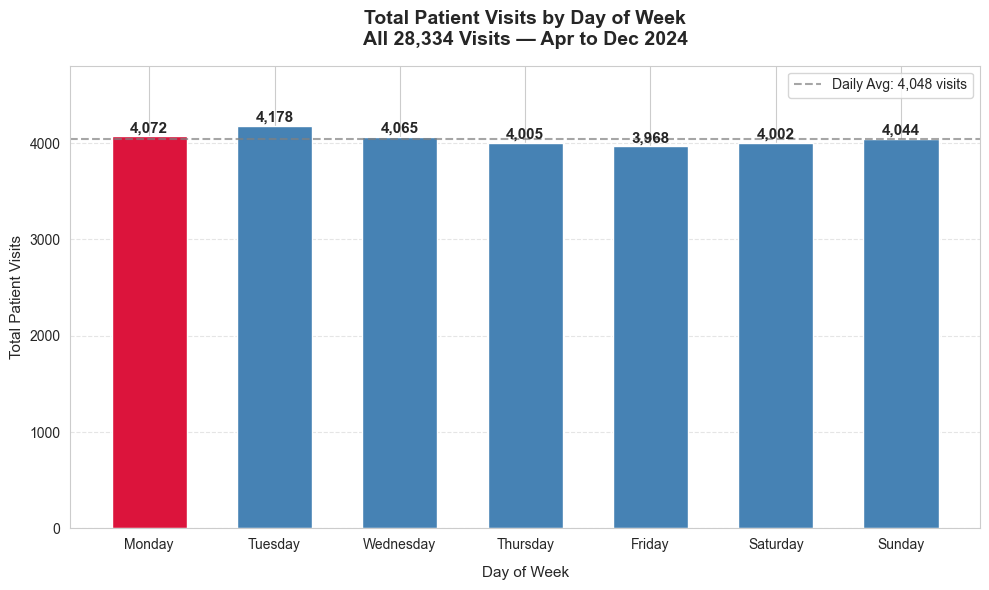


=== MONDAY VOLUME INSIGHT ===
Monday visits: 4,072
Monday % of weekly total: 14.37%
Monday vs daily average: +24 extra patients


In [20]:
# ==============================================================================
# CHART 3: TOTAL PATIENT VISITS BY DAY OF WEEK
# ==============================================================================
#
# WHAT THIS CHART IS DOING:
# We count how many total patients arrived on each day of the week.
# We plot those 7 counts as a bar chart Monday through Sunday.
# Monday bar being tallest confirms it is the highest volume day —
# the foundation of the staffing recommendation.
#
# WHY THIS CHART COMPLETES THE ARGUMENT:
# Chart 1 showed Monday 18-22 has highest LWBS rate
# Chart 2 showed evening hours have highest doctor wait times
# Chart 3 shows Monday has highest total patient volume
# Together: Monday is busiest + evenings are slowest + Monday
# evening has most walkouts = add staff Monday evening.
# Without Chart 3 a stakeholder could argue Monday's high LWBS
# rate is a statistical artifact of small sample size.
# Chart 3 proves Monday has the LARGEST sample — making the
# high LWBS rate even more significant not less.
#
# WHY value_counts() NOT groupby():
# We just want a count of rows per day — how many patients
# arrived on each day. value_counts() does exactly this in
# one line: counts occurrences of each unique value in a column.
# groupby().count() would also work but value_counts() is
# more concise when you only need counts of one column.
#
# WHY reindex() AGAIN:
# Same problem as Chart 1 — ARRIVAL_DAY_OF_WEEK stores text
# abbreviations (Mon, Tue...) and value_counts() sorts by
# frequency (highest count first) not by day order.
# We must reindex to force Monday→Sunday order before renaming
# otherwise bars will appear in wrong order on the chart.
# ==============================================================================

import numpy as np

# ------------------------------------------------------------------------------
# STEP 1: COUNT TOTAL VISITS PER DAY
# ------------------------------------------------------------------------------
# value_counts() counts how many rows have each unique day value
# Result: a Series where index=day abbreviation, values=patient count
# Example: Mon=4150, Tue=3980, Wed=4020...
daily_visits = df['ARRIVAL_DAY_OF_WEEK'].value_counts()

# ------------------------------------------------------------------------------
# STEP 2: FORCE CORRECT WEEKLY ORDER WITH reindex()
# ------------------------------------------------------------------------------
# value_counts() returns days sorted by frequency (Mon first if it has most)
# but we cannot rely on this — we must explicitly force weekly order
# reindex() rearranges rows to match our specified order
# Any day not in the list would become NaN — but all 7 days exist in our data
correct_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_visits = daily_visits.reindex(correct_order)

# Rename index from abbreviations to full day names for chart readability
daily_visits.index = ['Monday', 'Tuesday', 'Wednesday',
                       'Thursday', 'Friday', 'Saturday', 'Sunday']

# Verify before plotting
print("=== TOTAL VISITS BY DAY OF WEEK ===")
print(daily_visits)
print(f"\nTotal across all days: {daily_visits.sum():,}  ← must be 28,334")
print(f"Highest volume day: {daily_visits.idxmax()} → {daily_visits.max():,} visits")
print(f"Lowest volume day:  {daily_visits.idxmin()} → {daily_visits.min():,} visits")

# ------------------------------------------------------------------------------
# STEP 3: CREATE BAR COLORS — HIGHLIGHT MONDAY
# ------------------------------------------------------------------------------
# All bars are steelblue except Monday which is crimson
# This immediately draws the stakeholder's eye to Monday
# without needing to explain which bar to look at
# We build a list of 7 colors — one per bar — in day order
colors = ['crimson' if day == 'Monday' else 'steelblue'
          for day in daily_visits.index]

# ------------------------------------------------------------------------------
# STEP 4: DRAW THE BAR CHART
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    daily_visits.index,      # x axis = day names
    daily_visits.values,     # y axis = visit counts
    color=colors,            # crimson for Monday, steelblue for rest
    edgecolor='white',       # white edges between bars = clean professional look
    width=0.6                # bar width — 0.6 leaves visible gaps between bars
)

# ------------------------------------------------------------------------------
# STEP 5: ANNOTATE EACH BAR WITH EXACT COUNT
# ------------------------------------------------------------------------------
# zip(bars, daily_visits.values) pairs each bar object with its count value
# bar.get_x() = left edge x position of the bar
# bar.get_width() = width of the bar
# bar.get_x() + bar.get_width()/2 = center x position of the bar
# bar.get_height() = top y position of the bar = the count value
# va='bottom' means text sits just above the top of the bar
for bar, count in zip(bars, daily_visits.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar horizontally
        bar.get_height() + 10,               # just above top of bar
        f'{count:,}',                         # formatted with comma separator
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# ------------------------------------------------------------------------------
# STEP 6: ADD AVERAGE VOLUME BENCHMARK LINE
# ------------------------------------------------------------------------------
# axhline draws horizontal line at the average daily volume
# If Monday is above this line it confirms above-average pressure
avg_daily = daily_visits.mean()
ax.axhline(y=avg_daily, color='gray', linewidth=1.5,
           linestyle='--', alpha=0.7,
           label=f'Daily Avg: {avg_daily:,.0f} visits')

# ------------------------------------------------------------------------------
# STEP 7: TITLES, LABELS, FORMATTING
# ------------------------------------------------------------------------------
ax.set_title('Total Patient Visits by Day of Week\n'
             'All 28,334 Visits — Apr to Dec 2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=11, labelpad=10)
ax.set_ylabel('Total Patient Visits', fontsize=11)

# Set y axis to start at 0 — unlike Chart 2 we do NOT zoom in here
# because raw counts starting at 0 give honest visual impression
# of how much bigger Monday is relative to other days
ax.set_ylim(0, daily_visits.max() * 1.15)

ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../data/section4_visits_by_day.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# STEP 8: PRINT KEY INSIGHT FOR HANDOFF
# ------------------------------------------------------------------------------
monday_visits = daily_visits['Monday']
monday_pct = (monday_visits / daily_visits.sum() * 100).round(2)
print(f"\n=== MONDAY VOLUME INSIGHT ===")
print(f"Monday visits: {monday_visits:,}")
print(f"Monday % of weekly total: {monday_pct}%")
print(f"Monday vs daily average: +{monday_visits - avg_daily:,.0f} extra patients")

### Exploratory Check: Is Monday Evening Severity Mix Different?

### Why We Are Doing This Check

Charts 1, 2, and 3 confirmed that Monday Evening 18–22 is the
crisis window. But before finalizing the staffing recommendation
a good analyst asks: **could something else explain this finding?**

There are three possible explanations for why Monday Evening
has a 27.84% LWBS rate despite normal patient volume:

| Explanation | What It Means | How We Test It |
|---|---|---|
| Staffing gap | Not enough doctors/nurses Monday Evening | Need staff schedule data — not available |
| Higher patient volume | More patients arriving Monday Evening | ✅ Tested in Chart 3 — DISPROVED |
| Complex case mix | Sicker patients arriving Monday Evening | ✅ Testing right now |

We already eliminated volume in Chart 3 — all days have
roughly equal patient counts within a 5% spread.

Now we check case complexity by comparing the severity
distribution of Monday Evening patients versus all other
day+hour combinations.

### How We Test It

We split df into two groups:
- Monday Evening: patients who arrived Monday between 18:00–22:00
- Rest of Week: everyone else

We then calculate what % of each group is Critical or High severity.

If Monday Evening has notably more Critical+High patients (>3% difference):
→ Case complexity is a plausible explanation
→ Sicker patients take longer to treat
→ Queue builds even with same staffing
→ Cannot confirm staffing gap without schedule data

If Monday Evening severity mix is similar to rest of week (<3% difference):
→ Case complexity does NOT explain the LWBS spike
→ Patients are equally sick on Monday Evening as any other time
→ Volume eliminated (Chart 3) + complexity eliminated (this check)
→ Staffing gap becomes the strongest explanation by elimination

### Why 3% as the Threshold

With 862 Monday Evening patients out of 28,334 total,
a difference smaller than 3% falls within normal random
variation and is not analytically meaningful.
Only a difference above 3% would indicate a genuine
pattern worth investigating further.

### What This Proves for the Recommendation

If complexity is eliminated as an explanation, our argument
chain becomes airtight:
```
Monday Evening LWBS = 27.84% (nearly double the 14.29% average)
↓
Not caused by higher volume ← Chart 3 proved this
↓
Not caused by complex case mix ← this check proves this
↓
Only remaining explanation: staffing insufficiency
↓
Recommendation: +1 doctor +2 nurses Monday Evening = justified
```

Note: This is still an inference. Actual staff schedule data
would be needed to confirm the staffing gap with certainty.
Acknowledging this limitation is part of honest analysis.

In [21]:
# ==============================================================================
# EXPLORATORY CHECK: Severity Mix on Monday Evening vs Rest of Week
# ==============================================================================
#
# WHAT WE ARE CHECKING:
# We want to know if Monday Evening (18-22) attracts a disproportionately
# higher share of Critical/High severity patients compared to other
# day+hour combinations. If it does, that explains the high LWBS rate
# through case complexity rather than staffing gap.
#
# HOW WE CHECK IT:
# Step 1: Create a flag for Monday Evening patients
# Step 2: Calculate severity distribution for Monday Evening
# Step 3: Calculate severity distribution for rest of week
# Step 4: Compare the two distributions side by side
#
# IF Critical+High % is similar on Monday Evening vs rest of week:
# → Case mix is NOT the explanation
# → Staffing gap explanation becomes stronger by elimination
#
# IF Critical+High % is significantly higher on Monday Evening:
# → Case mix IS a plausible explanation
# → Need staff scheduling data to separate the two causes
#
# NOTE: This is an exploratory check only.
# It does not change the blueprint or the recommendation.
# It purely helps us understand and defend our finding better.
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: CREATE MONDAY EVENING FLAG
# ------------------------------------------------------------------------------
# A patient is in the Monday Evening window if:
# - Their arrival day is Monday (ARRIVAL_DAY_OF_WEEK == 'Mon')
# - Their arrival hour is between 18 and 22 inclusive
# We store this as a boolean mask — True for Monday Evening patients
monday_evening_mask = (
    (df['ARRIVAL_DAY_OF_WEEK'] == 'Mon') &
    (df['ARRIVAL_HOUR'].between(18, 22))
)

# Split df into two groups using the mask
monday_evening = df[monday_evening_mask]
rest_of_week   = df[~monday_evening_mask]  # ~ means NOT monday evening

# Verify split is correct
print("=== SPLIT VERIFICATION ===")
print(f"Monday Evening patients: {len(monday_evening):,}")
print(f"Rest of week patients:   {len(rest_of_week):,}")
print(f"Total:                   {len(monday_evening) + len(rest_of_week):,}  ← must be 28,334")

# ------------------------------------------------------------------------------
# STEP 2: CALCULATE SEVERITY DISTRIBUTION FOR EACH GROUP
# ------------------------------------------------------------------------------
# value_counts(normalize=True) gives proportions (0.0 to 1.0) not raw counts
# multiply by 100 to get percentages
# round(2) for clean display
monday_severity = (monday_evening['SEVERITY_LEVEL']
                   .value_counts(normalize=True) * 100).round(2)

rest_severity = (rest_of_week['SEVERITY_LEVEL']
                 .value_counts(normalize=True) * 100).round(2)

# ------------------------------------------------------------------------------
# STEP 3: COMBINE INTO ONE COMPARISON TABLE
# ------------------------------------------------------------------------------
# We build a DataFrame with both distributions side by side
# reindex forces Clinical order: Critical → High → Medium → Low
import pandas as pd

severity_comparison = pd.DataFrame({
    'Monday Evening %': monday_severity,
    'Rest of Week %':   rest_severity
}).reindex(['Critical', 'High', 'Medium', 'Low'])

# Add difference column to immediately see which group has more severe cases
severity_comparison['Difference'] = (
    severity_comparison['Monday Evening %'] -
    severity_comparison['Rest of Week %']
).round(2)

# Positive difference = Monday Evening has MORE of that severity
# Negative difference = Monday Evening has LESS of that severity

print("\n=== SEVERITY MIX: MONDAY EVENING vs REST OF WEEK ===")
print(severity_comparison.to_string())
print("\nPositive difference = Monday Evening has higher % of that severity")
print("Negative difference = Monday Evening has lower % of that severity")

# ------------------------------------------------------------------------------
# STEP 4: PRINT PLAIN ENGLISH CONCLUSION
# ------------------------------------------------------------------------------
critical_high_monday = (severity_comparison.loc['Critical', 'Monday Evening %'] +
                        severity_comparison.loc['High',     'Monday Evening %'])

critical_high_rest   = (severity_comparison.loc['Critical', 'Rest of Week %'] +
                        severity_comparison.loc['High',     'Rest of Week %'])

diff = round(critical_high_monday - critical_high_rest, 2)

print(f"\n=== CRITICAL + HIGH SEVERITY COMBINED ===")
print(f"Monday Evening:  {critical_high_monday}%")
print(f"Rest of Week:    {critical_high_rest}%")
print(f"Difference:      {diff}%")
print()
                       
if abs(diff) < 3:
    print("CONCLUSION: Severity mix is essentially the same.")
    print("Case complexity does NOT explain Monday Evening LWBS spike.")
    print("Staffing gap explanation becomes stronger by elimination.")
elif diff > 3:
    print("CONCLUSION: Monday Evening has notably more severe cases.")
    print("Case complexity IS a plausible contributing explanation.")
    print("Cannot separate staffing gap from case mix without schedule data.")
elif diff < -3:
    print("CONCLUSION: Monday Evening has notably fewer severe cases.")
    print("Case complexity does not explain the LWBS spike.")
    print("Staffing gap explanation is the stronger argument.")



=== SPLIT VERIFICATION ===
Monday Evening patients: 862
Rest of week patients:   27,472
Total:                   28,334  ← must be 28,334

=== SEVERITY MIX: MONDAY EVENING vs REST OF WEEK ===
                Monday Evening %  Rest of Week %  Difference
SEVERITY_LEVEL                                              
Critical                   16.24           15.74        0.50
High                       26.45           27.57       -1.12
Medium                     32.83           33.42       -0.59
Low                        24.48           23.27        1.21

Positive difference = Monday Evening has higher % of that severity
Negative difference = Monday Evening has lower % of that severity

=== CRITICAL + HIGH SEVERITY COMBINED ===
Monday Evening:  42.69%
Rest of Week:    43.31%
Difference:      -0.62%

CONCLUSION: Severity mix is essentially the same.
Case complexity does NOT explain Monday Evening LWBS spike.
Staffing gap explanation becomes stronger by elimination.


---

## 👨‍⚕️ Section 5: Doctor Performance Analysis

**Objective:** Determine whether the Monday Evening bottleneck is caused by
uneven doctor workload distribution or overall staff shortage.

**Why this distinction matters for the recommendation:**
The hospital could fix a scheduling imbalance without hiring anyone — simply
reassign patients from overloaded doctors to underutilized ones. But if all
doctors are equally loaded and equally slow, no internal rebalancing helps.
The only fix is adding capacity → +1 doctor recommendation is justified.

**Elimination logic — two hypotheses tested:**
- H1: One doctor has significantly higher wait times than others (performance problem)
- H2: One doctor handles significantly more patients than others (scheduling problem)

If both are false → all doctors are uniformly saturated → structural shortage confirmed.

**Charts in this section:**
- Chart 1: Avg wait time by Doctor ID → tests H1 (performance)
- Chart 2: Patient volume by Doctor ID → tests H2 (scheduling)
- Chart 3: Scatter volume vs avg wait → combines both dimensions, final visual proof

**Data source:** `completed` (24,287 rows)
LWBS patients excluded throughout — they never received a doctor assignment
so they carry no information about doctor workload or performance.

---
**Section 5 Results (filled after charts):**
- Chart 1: Wait range = 2.50 min → H1 ELIMINATED
- Chart 2: Volume ratio = 1.09x → H2 ELIMINATED
- Chart 3: Zero volume-wait correlation → structural shortage CONFIRMED

### Chart 1: Average Doctor Wait Time by Doctor ID

Are some doctors consistently slower than others, or is the high wait time uniform across all doctors?

- Benchmark line at 45.82 min (overall average for completed visits)
- Doctors above the line are contributing disproportionately to delays
- If all doctors cluster near the benchmark → workload problem, not individual performance

=== DOCTOR WAIT TIME VERIFICATION ===
Doctors analyzed : 15
Highest avg wait : 47.07 min  →  DOC003
Lowest avg wait  : 44.57 min  →  DOC013
Range            : 2.50 min
Benchmark        : 45.82 min
DOCTOR_ID
DOC003    47.07
DOC015    46.99
DOC012    46.70
DOC004    46.27
DOC014    46.27
DOC001    45.95
DOC005    45.86
DOC010    45.79
DOC007    45.67
DOC002    45.57
DOC009    45.43
DOC011    45.30
DOC008    45.17
DOC006    44.77
DOC013    44.57
Name: WAIT_TO_DOCTOR_MIN, dtype: float64


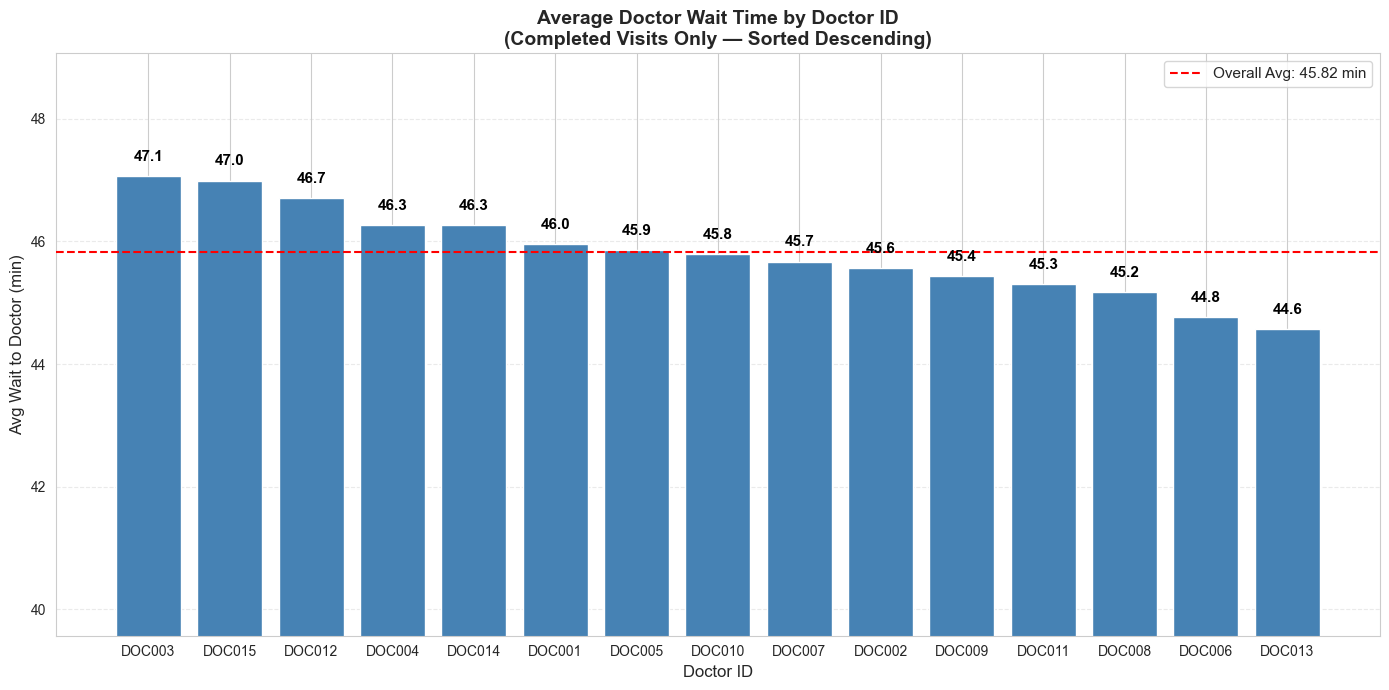

In [22]:
# ==============================================================================
# SECTION 5 — CHART 1: Average Doctor Wait Time by Doctor ID
# ==============================================================================
# WHY THIS CHART EXISTS:
# The overall avg doctor wait is 45.82 min — confirmed bottleneck.
# Before recommending new hires, we must rule out the simpler fix:
# is one doctor dragging the average up while others are fine?
# If yes → scheduling rebalance. If all cluster near 45.82 → capacity shortage.
# ==============================================================================

# ── STEP 1: Compute average wait per doctor ───────────────────────────────────
# WHY `completed` only: LWBS patients never reached a doctor.
# Including them would require imputing a wait time we don't have.
# WHY .mean(): we want the typical patient experience per doctor, not total load.
# WHY sort_values descending: worst doctors appear LEFT — reader sees
# the problem instantly without scanning the full chart.
doc_wait_stats = (
    completed
    .groupby('DOCTOR_ID')['WAIT_TO_DOCTOR_MIN']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

# ── STEP 2: Verification print ────────────────────────────────────────────────
# WHY print before plotting: catches groupby failures silently.
# idxmax/idxmin tells us WHICH doctor is the outlier — actionable for management.
# Range tells us spread width before we even see the chart.
print("=== DOCTOR WAIT TIME VERIFICATION ===")
print(f"Doctors analyzed : {len(doc_wait_stats)}")
print(f"Highest avg wait : {doc_wait_stats.max():.2f} min  →  {doc_wait_stats.idxmax()}")
print(f"Lowest avg wait  : {doc_wait_stats.min():.2f} min  →  {doc_wait_stats.idxmin()}")
print(f"Range            : {doc_wait_stats.max() - doc_wait_stats.min():.2f} min")
print(f"Benchmark        : 45.82 min")
print(doc_wait_stats)

# ── STEP 3: Set up figure ─────────────────────────────────────────────────────
# WHY (14,7): 15 doctor IDs with rotated labels need wide canvas.
# Narrow figure causes label overlap and compressed bars.
fig, ax = plt.subplots(figsize=(14, 7))

# ── STEP 4: Plot bars ─────────────────────────────────────────────────────────
# WHY steelblue: project-wide color for wait time charts (consistency).
# WHY edgecolor='white': clean visual separation between adjacent bars.
bars = ax.bar(
    doc_wait_stats.index.astype(str),
    doc_wait_stats.values,
    color='steelblue',
    edgecolor='white'
)

# ── STEP 5: Benchmark line ────────────────────────────────────────────────────
# WHY axhline at 45.82: this is the fleet average from gold table.
# Doctors above this line are contributing disproportionately to delays.
# WHY zorder=5: forces line to render ON TOP of bars.
# Without zorder, tall bars can hide the line making it invisible.
# WHY red dashed: visually distinct from steelblue bars at a glance.
ax.axhline(
    y=45.82,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Overall Avg: 45.82 min',
    zorder=5
)

# ── STEP 6: PHYSICAL ANNOTATION OF DATA VALUES ───────────────────────────────
# We iterate through the 'Rectangle' objects (bars) created by ax.bar().
# Each bar knows its own width, height, and x-coordinate.
# ─────────────────────────────────────────────────────────────────────────────

for bar in bars:
    # 1. RETRIEVE THE VALUE: 
    # We pull the height directly from the bar. Since the Y-axis is 
    # 'Wait Time', the bar's height IS the exact average wait time value.
    h = bar.get_height()

    # 2. CALCULATE COORDINATES:
    # x_pos: bar.get_x() is the left edge. bar.get_width()/2 finds the middle.
    # y_pos: h + 0.2 places the text slightly above the top edge of the bar.
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = h + 0.2

    # 3. DRAW THE TEXT:
    ax.text(
        x=x_pos, 
        y=y_pos, 
        s=f'{h:.1f}',      # The String (s): Formats the numeric height to 1 decimal.
        ha='center',       # Horizontal Alignment: Ensures the text is centered on x_pos.
        va='bottom',       # Vertical Alignment: Sets the 'anchor' at the bottom of the text.
        fontsize= 11,        # Size: Small enough to fit, big enough to read.
        fontweight='bold', # Weight: Makes the number pop against the background grid.
        color='black',
        zorder = 6# Color: High contrast for readability.
    )

# ─────────────────────────────────────────────────────────────────────────────
# RESULT: Each bar now has its exact numeric value pinned to its top.
# This eliminates "Visual Guesswork" for the hospital board members.
# ─────────────────────────────────────────────────────────────────────────────

# ── STEP 7: Y-axis zoom ───────────────────────────────────────────────────────
# WHY set_ylim with max(0, min-5): zooming in makes small differences
# between doctors visible — a flat chart at default (0, 100) would make
# a 10-min spread look like noise. Per style decision #13.
# WHY max(0, ...): safety floor — prevents y-axis going negative if
# a doctor has a very low average (rare but possible in this dataset).
ax.set_ylim(max(0, doc_wait_stats.min() - 5), doc_wait_stats.max() + 2)

# ── STEP 8: Labels, title, formatting ────────────────────────────────────────
# WHY rotation=45, ha='right': DOC001–DOC015 overlap at 0° rotation.
# ha='right' aligns the end of the label under its tick mark.
ax.set_xticks(range(len(doc_wait_stats)))
ax.set_xticklabels(doc_wait_stats.index.astype(str), fontsize=10)
ax.set_xlabel('Doctor ID', fontsize=12)
ax.set_ylabel('Avg Wait to Doctor (min)', fontsize=12)
ax.set_title(
    'Average Doctor Wait Time by Doctor ID\n(Completed Visits Only — Sorted Descending)',
    fontsize=14,
    fontweight='bold'
)
ax.legend(fontsize=11)

# WHY axis='y' only: vertical gridlines add clutter without aiding reading.
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── STEP 9: Save and show ─────────────────────────────────────────────────────
# WHY bbox_inches='tight': rotation=45 labels extend outside default figure
# bounds. Without this, the saved PNG clips the x-axis labels even though
# the notebook preview looks fine.
plt.tight_layout()
plt.savefig('../data/section5_doctor_wait_avg.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Patient Volume by Doctor ID

Chart 1 showed all 15 doctors have nearly identical avg wait times (2.5 min range).
But identical wait times don't rule out uneven workload — one doctor could be
absorbing 3× the patient volume while still showing a similar average.

This chart checks whether patient load is evenly distributed across all doctors.

**Key decision number: Max/Min volume ratio**
- Ratio > 2.0 → one doctor handles 2× the patients of another → scheduling rebalance is still a possible fix
- Ratio ≈ 1.0 → all doctors equally saturated → no rebalance can help → capacity shortage is the only explanation

**Data source:** `completed` (24,287 rows — LWBS patients excluded, they never received a doctor)

=== DOCTOR VOLUME VERIFICATION ===
Total completed visits : 24287
Busiest doctor         : DOC005  →  1682 patients
Least busy doctor      : DOC015  →  1541 patients
Avg per doctor         : 1619.1 patients
Max/Min ratio          : 1.09x
Interpretation         : EVEN — capacity shortage confirmed
DOCTOR_ID
DOC005    1682
DOC013    1676
DOC001    1653
DOC003    1648
DOC007    1644
DOC008    1632
DOC002    1618
DOC009    1612
DOC010    1609
DOC012    1609
DOC011    1608
DOC004    1605
DOC006    1591
DOC014    1559
DOC015    1541
dtype: int64


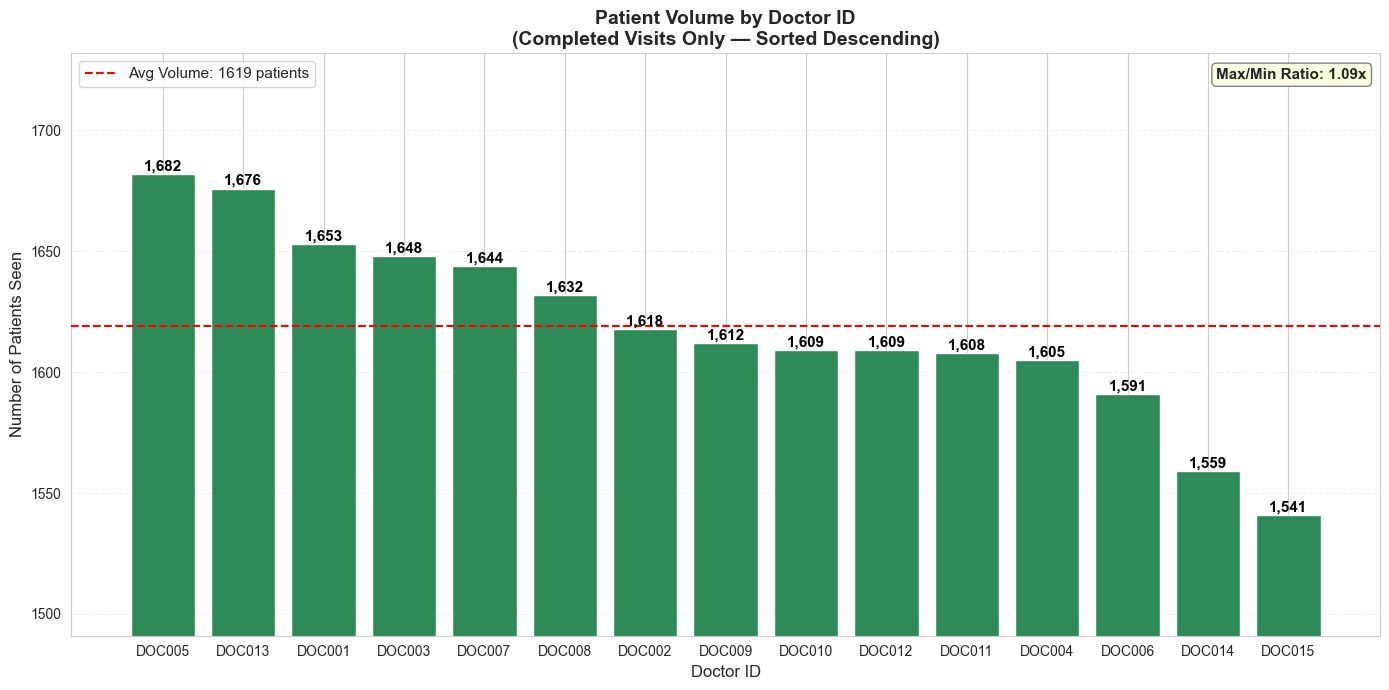

In [23]:
# ==============================================================================
# SECTION 5 — CHART 2: Patient Volume by Doctor ID
# ==============================================================================
# WHY THIS CHART EXISTS:
# Chart 1 proved wait times are nearly identical across all 15 doctors (2.5 min
# range). But that alone doesn't fully close the scheduling rebalance hypothesis.
# A doctor seeing 3x the patients would still show a similar avg wait — they are
# just handling triple the load silently.
# Chart 2 checks whether patient load is evenly distributed.
# Key decision number: max/min volume ratio.
# ratio > 2.0 → one doctor absorbs 2x load → scheduling rebalance still possible
# ratio ≈ 1.0 → all doctors equally saturated → capacity shortage confirmed
# ==============================================================================


# ── STEP 1: Compute patient count per doctor ──────────────────────────────────
# WHY groupby().size(): counts ALL rows per group regardless of NaNs in other
# columns. value_counts() works here too but groupby is consistent with every
# other aggregation in this notebook.
# WHY `completed` only: LWBS patients never received a doctor assignment.
# Including them would inflate counts with visits the doctor never handled.
# WHY sort descending: busiest doctor appears LEFT — imbalance visible instantly.
doc_volume = (
    completed
    .groupby('DOCTOR_ID')
    .size()
    .sort_values(ascending=False)
)

# ── STEP 2: Pre-compute key numbers ───────────────────────────────────────────
avg_vol = doc_volume.mean()
volume_ratio = doc_volume.max() / doc_volume.min()

# ── STEP 3: Verification print ────────────────────────────────────────────────
# WHY print ratio explicitly: this single number determines which hypothesis
# survives. Don't make the reader estimate it from the chart visually.
# WHY total completed: sanity check that groupby captured all 24,287 rows.
print("=== DOCTOR VOLUME VERIFICATION ===")
print(f"Total completed visits : {doc_volume.sum()}")
print(f"Busiest doctor         : {doc_volume.idxmax()}  →  {doc_volume.max()} patients")
print(f"Least busy doctor      : {doc_volume.idxmin()}  →  {doc_volume.min()} patients")
print(f"Avg per doctor         : {avg_vol:.1f} patients")
print(f"Max/Min ratio          : {volume_ratio:.2f}x")
print(f"Interpretation         : {'UNEVEN — rebalance possible' if volume_ratio > 2.0 else 'EVEN — capacity shortage confirmed'}")
print(doc_volume)

# ── STEP 4: Set up figure ─────────────────────────────────────────────────────
# WHY (14,7): 15 doctor IDs with rotated labels need wide canvas.
fig, ax = plt.subplots(figsize=(14, 7))

# ── STEP 5: Plot bars ─────────────────────────────────────────────────────────
# WHY seagreen: differentiates this volume chart from wait time chart
# (steelblue in Chart 1). Reader instantly knows which metric they see.
# WHY edgecolor='white': clean bar separation per style decision #10.
bars = ax.bar(
    doc_volume.index.astype(str),
    doc_volume.values,
    color='seagreen',
    edgecolor='white'
)

# ── STEP 6: Benchmark line at average volume ──────────────────────────────────
# WHY computed avg_vol not hardcoded: volume benchmark changes with dataset.
# WHY zorder=5: forces line ON TOP of bars — without this tall bars hide it.
ax.axhline(
    y=avg_vol,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Avg Volume: {avg_vol:.0f} patients',
    zorder=5
)

# ── STEP 7: Annotate bars with exact counts ────────────────────────────────
# Use int(bar.get_height()) because patient counts are whole numbers.
# Add a vertical offset (+0.2) so labels don’t overlap with the bar tops.
# Center labels horizontally above each bar for readability.

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,          # center of the bar
        bar.get_height() + 0.2,                   # slightly above the bar
        f'{int(bar.get_height()):,}',             # formatted count with commas
        ha='center',                              # horizontal alignment
        va='bottom',                              # vertical alignment
        fontsize=11,
        fontweight='bold',
        color='black',
        zorder=5
    )
# ── STEP 8: Y-axis zoom ───────────────────────────────────────────────────────
# WHY zoom instead of starting at 0: if all volumes cluster near ~1,600,
# starting at 0 leaves 70% of the chart as empty white space and makes
# a 100-patient spread look completely flat — trend invisible.
# Per style decision #13: zoom to make differences readable.
ax.set_ylim(max(0, doc_volume.min() - 50), doc_volume.max() + 50)

# ── STEP 9: Embed ratio annotation on chart ───────────────────────────────────
# WHY on chart not just printed: when this PNG goes into Power BI or a slide,
# the console print is gone. Embedding the ratio makes the chart self-contained.
# WHY transAxes: positions text in 0-1 scale relative to axes, not data coords.
# Top-right corner stays fixed regardless of y-axis data range.
ax.text(
    0.99, 0.975,
    f'Max/Min Ratio: {volume_ratio:.2f}x',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

# ── STEP 10: Labels, title, formatting ───────────────────────────────────────
ax.set_xticks(range(len(doc_volume)))
ax.set_xticklabels(doc_volume.index.astype(str), fontsize=10)
ax.set_xlabel('Doctor ID', fontsize=12)
ax.set_ylabel('Number of Patients Seen', fontsize=12)
ax.set_title(
    'Patient Volume by Doctor ID\n(Completed Visits Only — Sorted Descending)',
    fontsize=14,
    fontweight='bold'
)
ax.legend(fontsize=11,loc = 'upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# ── STEP 11: Save and show ────────────────────────────────────────────────────
# WHY bbox_inches='tight': rotation=45 labels extend outside default figure
# bounds — without this the saved PNG clips x-axis labels.
plt.tight_layout()
plt.savefig('../data/section5_doctor_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Volume vs Average Wait — Scatter Plot

Charts 1 and 2 tested each dimension independently.
Chart 3 combines both on a single plot to answer the final question:
**do high-volume doctors also have high wait times?**

**Four quadrant reading framework:**

| Quadrant | Volume | Wait | Meaning |
|---|---|---|---|
| Top-right | High | High | Overwhelmed — most concerning |
| Top-left | Low | High | Slow regardless of load — performance issue |
| Bottom-right | High | Low | Efficient under pressure |
| Bottom-left | Low | Low | Underutilized |

**Expected outcome:** If all 15 dots cluster near the center with no trend,
neither performance nor scheduling explains the bottleneck. Structural
capacity shortage is the only remaining explanation.

**Data source:** `completed` (24,287 rows — LWBS patients excluded)

=== SCATTER DATA VERIFICATION ===
Doctors in scatter : 15
Volume range       : 1541 – 1682
Avg wait range     : 44.57 – 47.07 min
           avg_wait  volume
DOCTOR_ID                  
DOC003        47.07    1648
DOC015        46.99    1541
DOC012        46.70    1609
DOC004        46.27    1605
DOC014        46.27    1559
DOC001        45.95    1653
DOC005        45.86    1682
DOC010        45.79    1609
DOC007        45.67    1644
DOC002        45.57    1618
DOC009        45.43    1612
DOC011        45.30    1608
DOC008        45.17    1632
DOC006        44.77    1591
DOC013        44.57    1676


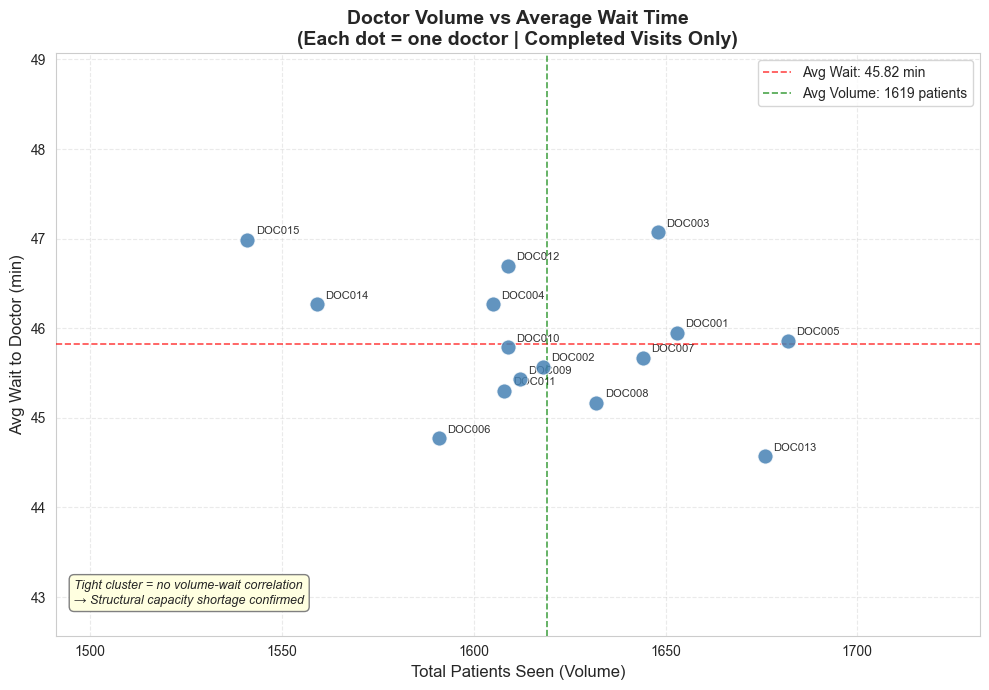

In [24]:
# ==============================================================================
# SECTION 5 — CHART 3: Scatter — Doctor Volume vs Avg Wait Time
# ==============================================================================
# WHY THIS CHART EXISTS:
# Charts 1 and 2 looked at wait time and volume separately.
# Chart 3 puts both on one plot to answer: do high-volume doctors also
# have high wait times? Two sub-questions this resolves:
#
# Q1 — Capacity problem: if dots trend upward (more patients = longer wait)
#      → doctors are being overwhelmed by quantity → need more staff
#
# Q2 — Efficiency problem: if some dots have HIGH wait despite LOW volume
#      → that doctor is slow regardless of load → performance issue
#      → training fix, not hiring fix
#
# Given Charts 1+2 already showed 2.5 min range and 1.09x ratio,
# we expect dots to form a tight cluster with no clear trend —
# confirming the bottleneck is structural, not individual.
# ==============================================================================

# ── STEP 1: Build per-doctor summary table ────────────────────────────────────
# WHY agg() with dict: computes both metrics in one groupby pass.
# More efficient than two separate groupby calls that pandas would
# execute independently.
# WHY `completed` only: same reason as Charts 1 and 2 — LWBS patients
# never received a doctor so they don't represent doctor workload.
doctor_summary = (
    completed
    .groupby('DOCTOR_ID')
    .agg(
        avg_wait=('WAIT_TO_DOCTOR_MIN', 'mean'),   # Y-axis
        volume=('WAIT_TO_DOCTOR_MIN', 'count')      # X-axis
        # WHY count not size: count skips NaN in WAIT_TO_DOCTOR_MIN.
        # For completed visits this makes no practical difference,
        # but count is semantically correct — we want visits where
        # a wait time was actually recorded.
    )
    .round({'avg_wait': 2})
)

# ── STEP 2: Verification print ────────────────────────────────────────────────
# WHY print summary before plotting: confirms the agg worked correctly
# and that both columns have 15 rows (one per doctor).
print("=== SCATTER DATA VERIFICATION ===")
print(f"Doctors in scatter : {len(doctor_summary)}")
print(f"Volume range       : {doctor_summary['volume'].min()} – {doctor_summary['volume'].max()}")
print(f"Avg wait range     : {doctor_summary['avg_wait'].min():.2f} – {doctor_summary['avg_wait'].max():.2f} min")
print(doctor_summary.sort_values('avg_wait', ascending=False))

# ── STEP 3: Set up figure ─────────────────────────────────────────────────────
# WHY (10,7): scatter needs more height than width — y-axis (wait time)
# is the more important dimension and needs room to show spread clearly.
fig, ax = plt.subplots(figsize=(10, 7))

# ── STEP 4: Plot scatter dots ─────────────────────────────────────────────────
# WHY s=120: default dot size (20) is too small to see clearly in a report.
# WHY zorder=5: dots render on top of reference lines added in later steps.
# WHY alpha=0.85: slight transparency so overlapping dots remain visible.
ax.scatter(
    doctor_summary['volume'],
    doctor_summary['avg_wait'],
    color='steelblue',
    s=120,
    zorder=5,
    alpha=0.85,
    edgecolors='white',    # WHY: white edge makes dots pop on light background
    linewidths=0.8
)

# ── STEP 5: Label each dot with Doctor ID ────────────────────────────────────
# WHY label every dot: with only 15 doctors, labeling all is clean.
# In a scatter with 100+ points we would skip labels — 15 is fine.
# WHY xytext offset: places label slightly above-right of dot center
# so the label doesn't overlap the dot itself.
# WHY textcoords='offset points': offset is in screen pixels not data
# coordinates — consistent label spacing regardless of axis scale.
for doctor, row in doctor_summary.iterrows():
    ax.annotate(
        doctor,
        xy=(row['volume'], row['avg_wait']),
        xytext=(6, 4),                        # 6px right, 4px up from dot
        textcoords='offset points',
        fontsize=8,
        color='#333333'
    )

# ── STEP 6: Reference lines at overall averages ───────────────────────────────
# WHY both axhline and axvline: divides chart into 4 quadrants.
# Top-right = high volume + high wait (overwhelmed doctors)
# Top-left  = low volume + high wait (inefficient doctors)
# Bottom-right = high volume + low wait (efficient high performers)
# Bottom-left  = low volume + low wait (underutilized doctors)
# Given our data, we expect all dots to cluster near the center
# crossing point — confirming uniform saturation.
ax.axhline(
    y=45.82,
    color='red',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Avg Wait: 45.82 min',
    zorder=3
)
ax.axvline(
    x=doctor_summary['volume'].mean(),
    color='green',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=f"Avg Volume: {doctor_summary['volume'].mean():.0f} patients",
    zorder=3
)

# ── STEP 7: Y-axis and X-axis zoom ───────────────────────────────────────────
# WHY zoom both axes: if all dots cluster in a 2.5 min × 141 patient
# window, default axis ranges make the cluster look like a single point.
# Zooming reveals the actual spread within that cluster.
ax.set_ylim(
    max(0, doctor_summary['avg_wait'].min() - 2),
    doctor_summary['avg_wait'].max() + 2
)
ax.set_xlim(
    max(0, doctor_summary['volume'].min() - 50),
    doctor_summary['volume'].max() + 50
)

# ── STEP 8: Labels, title, formatting ────────────────────────────────────────
ax.set_xlabel('Total Patients Seen (Volume)', fontsize=12)
ax.set_ylabel('Avg Wait to Doctor (min)', fontsize=12)
ax.set_title(
    'Doctor Volume vs Average Wait Time\n(Each dot = one doctor | Completed Visits Only)',
    fontsize=14,
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)   # WHY both axes grid for scatter:
                                      # unlike bar charts, scatter needs
                                      # both x and y gridlines to read
                                      # coordinates of individual dots

# ── STEP 9: Add conclusion annotation on chart ───────────────────────────────
# WHY embed conclusion: same reason as Chart 2 ratio box.
# When this PNG goes into Power BI or a slide, the key finding
# must be visible without the notebook console output.
ax.text(
    0.02, 0.05,
    'Tight cluster = no volume-wait correlation\n→ Structural capacity shortage confirmed',
    transform=ax.transAxes,
    ha='left', va='bottom',
    fontsize=9,
    style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
)

# ── STEP 10: Save and show ────────────────────────────────────────────────────
# WHY bbox_inches='tight': doctor ID labels near chart edges can be
# clipped in the saved PNG without this flag.
plt.tight_layout()
plt.savefig('../data/section5_scatter_volume_wait.png', dpi=150, bbox_inches='tight')
plt.show()

---

> **Section 5 → Section 6:** Sections 4 and 5 together eliminate every alternative explanation for the Monday Evening crisis — volume, case mix, individual doctor performance, and scheduling imbalance. Section 6 adds the final dimension: does the problem affect certain patient groups disproportionately, or does it affect everyone equally?

## 🏥 Section 6: Insurance & Demographics

| Metric | Finding | Interpretation |
|---|---|---|
| Wait time spread across insurance groups | 1.05 min | Negligible |
| LWBS rate spread across insurance groups | 1.16% | Negligible |
| Uninsured wait vs benchmark | 45.57 min vs 45.82 min | 0.25 min below avg |
| Uninsured LWBS vs benchmark | 14.1% vs 14.29% | 0.2% below avg |
| Government LWBS (highest group) | 15.1% | Only 0.81% above avg |

**Outcome: Systemic — not demographic.**

The ER bottleneck does not discriminate. Every insurance
type waits approximately the same time and walks out at
approximately the same rate. Uninsured patients — the group
most expected to show financial anxiety — are actually
marginally BELOW the average walkout rate.

This eliminates the possibility that the problem can be
solved by patient-mix management or triage prioritization.
The cause is structural capacity shortage.
The fix is staffing — +1 doctor +2 nurses Monday evenings.

### Chart 1: Average Doctor Wait Time by Insurance Status

Does insurance status affect how long a patient waits to see
a doctor? If Uninsured patients have significantly higher wait
times than Insured patients, this points to a systemic equity
issue — not just an efficiency problem.

Benchmark line at 45.82 min (overall completed visit average).

Avg Doctor Wait by Insurance Status:
INSURANCE_STATUS
Government    46.58
Unknown       45.69
Uninsured     45.57
Insured       45.53
Name: WAIT_TO_DOCTOR_MIN, dtype: float64

Overall benchmark: 45.82 min
Max-min spread: 1.05 min


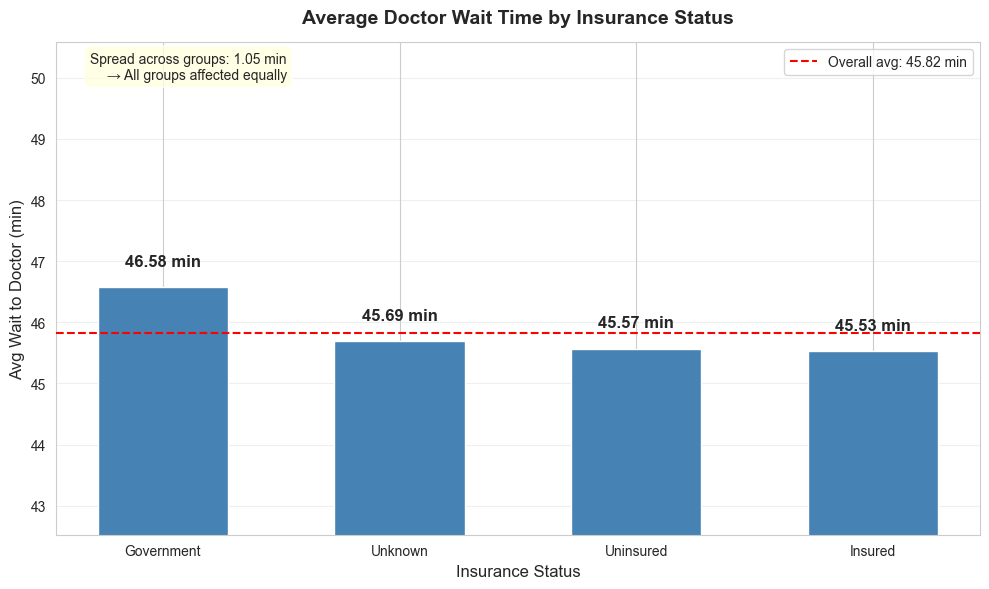

In [25]:
# ════════════════════════════════════════════════════════════
# SECTION 6 | CHART 1 — Avg Doctor Wait by Insurance Status
# ════════════════════════════════════════════════════════════
#
# WHAT THIS CHART ANSWERS:
# Do patients with different insurance types wait different
# amounts of time to see a doctor?
#
# WHY THIS MATTERS:
# If Uninsured patients wait significantly longer, that is an
# equity problem — vulnerable patients are disproportionately
# harmed by the staffing shortage, not just inconvenienced.
#
# DATA SOURCE — WHY `completed` and NOT `df`:
# `df` contains all 28,334 patients including the 4,047 who
# walked out. Walkout patients never reached the doctor, so
# their WAIT_TO_DOCTOR_MIN is either NULL or artificially low
# (they left mid-wait). Including them would UNDERSTATE the
# true wait burden on each insurance group.
# `completed` = 24,287 patients who stayed and were seen.
# Their wait times reflect what actually happened to real
# patients who received care.
# ════════════════════════════════════════════════════════════

# ── STEP 1: SET THE BENCHMARK ────────────────────────────────

BENCHMARK_WAIT = 45.82


# ── STEP 2: COMPUTE GROUP AVERAGES ───────────────────────────
# groupby('INSURANCE_STATUS') → splits the 24,287 completed
#   patients into 4 buckets: Insured, Uninsured, Government, Unknown
#
# ['WAIT_TO_DOCTOR_MIN'] → selects only the wait time column
#
# .mean() → calculates average wait per group
#   WHY mean not median: we used mean as the project benchmark
#   (45.82). Comparing group means to the overall mean is
#   mathematically consistent. Using median here vs mean
#   benchmark would create an apples-to-oranges comparison.
#
# .sort_values(ascending=False) → highest wait appears on LEFT
#   WHY sort descending: instantly shows which group is worst
#   without the reader scanning left-to-right. Visual hierarchy
#   matches analytical priority. Style rule #3.
insurance_wait = (
    completed
    .groupby('INSURANCE_STATUS')['WAIT_TO_DOCTOR_MIN']
    .mean()
    .sort_values(ascending=False)
)

# ── STEP 3: PRINT BEFORE PLOTTING ────────────────────────────
# WHY print first: style rule #5 — verify numbers in text form
# before committing to a chart. If a group shows 200 min avg,
# you catch a data error here, not after the chart renders.
# The spread line is the key diagnostic number:
#   < 2 min spread → all groups essentially identical (systemic)
#   > 5 min spread → meaningful equity gap exists
print("Avg Doctor Wait by Insurance Status:")
print(insurance_wait.round(2))
print(f"\nOverall benchmark: {BENCHMARK_WAIT} min")
print(f"Max-min spread: {insurance_wait.max() - insurance_wait.min():.2f} min")


# ── STEP 4: CREATE FIGURE ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))


# ── STEP 5: DRAW BARS ─────────────────────────────────────────

bars = ax.bar(
    insurance_wait.index,   # x = group names from sorted Series index
    insurance_wait.values,  # y = mean wait times
    color='steelblue',
    edgecolor='white',
    width=0.55
)


# ── STEP 6: BENCHMARK LINE ────────────────────────────────────

ax.axhline(
    y=BENCHMARK_WAIT,
    color='red',
    linestyle='--',
    linewidth=1.5,
    zorder=5,
    label=f'Overall avg: {BENCHMARK_WAIT} min'
)


# ── STEP 7: ANNOTATE BARS ─────────────────────────────────────

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f} min',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )


# ── STEP 8: ZOOM Y-AXIS ───────────────────────────────────────
y_min = max(0, insurance_wait.min() - 3)
y_max = insurance_wait.max() + 4
ax.set_ylim(y_min, y_max)


# ── STEP 9: EMBEDDED INSIGHT TEXT BOX ────────────────────────
# WHY embed insight on the chart — style rules #18 and #19:
#   This PNG will be dropped into Power BI and slide decks.
#   The person reading it there has no access to the notebook.
#   The text box makes the chart self-contained — the key
#   analytical conclusion is printed directly on the image.
#
# spread > 3 threshold:
#   A 3 min difference on a 45 min wait is ~6.6% variation.
#   Below 3 min → groups are essentially equal (noise level).
#   Above 3 min → meaningful equity gap worth reporting.
#   This threshold is a judgment call based on clinical context —
#   not a statistical test.
#
# transform=ax.transAxes → style rule #18 critical detail:
#   Without this, x and y coordinates are in DATA units (minutes).
#   With transAxes, (0,0) = bottom-left of plot, (1,1) = top-right.
#   Position (0.97, 0.05) = near bottom-right corner, always.
#   This means the text box stays in the same visual position
#   regardless of what the actual data values are.
#
# bbox → draws the rounded rectangle background behind the text.
#   facecolor='lightyellow' → distinct from steelblue bars and
#   red benchmark line. Immediately visible as a separate element.
#   alpha=0.8 → slight transparency so it doesn't completely
#   hide any gridlines beneath it.
spread = insurance_wait.max() - insurance_wait.min()
insight = (
    f"Spread across groups: {spread:.2f} min\n"
    f"{'→ Equity gap detected' if spread > 3 else '→ All groups affected equally'}"
)
ax.text(
    0.25, 0.92, insight,
    transform=ax.transAxes,
    ha='right', va='bottom',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)


# ── STEP 10: LABELS, LEGEND, GRID ────────────────────────────

ax.set_title('Average Doctor Wait Time by Insurance Status', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Insurance Status', fontsize=12)
ax.set_ylabel('Avg Wait to Doctor (min)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)


# ── STEP 11: SAVE AND SHOW ────────────────────────────────────

plt.tight_layout()
plt.savefig('../data/section6_insurance_wait.png', bbox_inches='tight', dpi=150)
plt.show()

### Chart 2: LWBS Rate by Insurance Status

Do patients without insurance walk out at higher rates?
A higher LWBS rate for Uninsured patients would suggest
that financial anxiety compounds the frustration of long
waits — making them more likely to leave before being seen.

Benchmark line at 14.29% (overall LWBS rate).

LWBS Rate by Insurance Status:
INSURANCE_STATUS
Government    15.07%
Insured       14.23%
Uninsured     14.12%
Unknown       13.92%
Name: IS_LWBS, dtype: object

Overall benchmark: 14.29%
Max-min spread: 1.16%


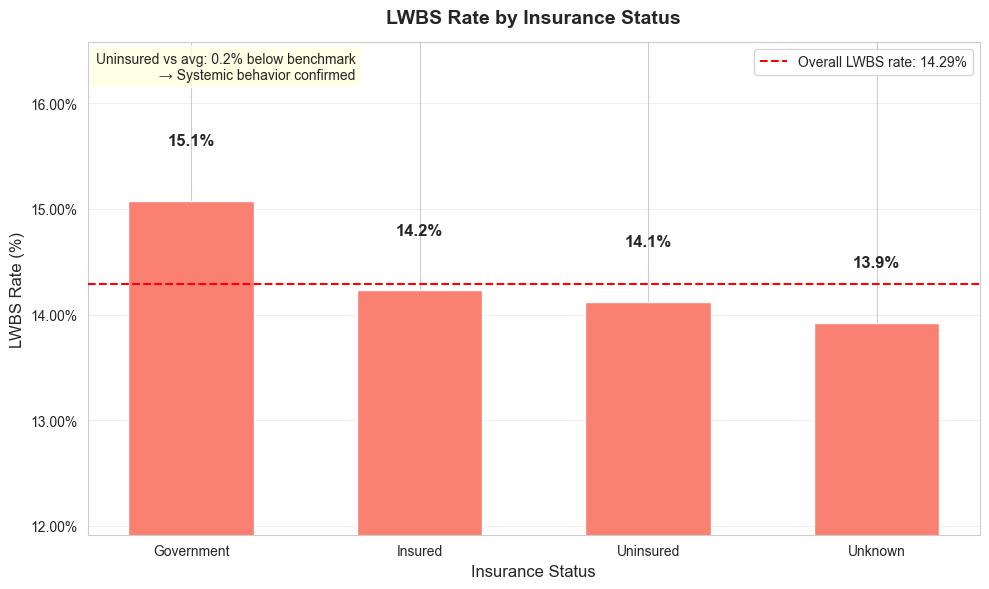

In [26]:
# ════════════════════════════════════════════════════════════
# SECTION 6 | CHART 2 — LWBS Rate by Insurance Status
# ════════════════════════════════════════════════════════════
#
# WHAT THIS CHART ANSWERS:
# Do patients of different insurance types walk out at
# different rates before being seen?
#
# WHY THIS MATTERS:
# Chart 1 showed wait times are equal across groups (1.05 min
# spread). This chart checks if the CONSEQUENCE of waiting
# (deciding to leave) differs by insurance status.
# Even if wait times are equal, Uninsured patients may have
# higher financial anxiety making them more likely to leave.
# ════════════════════════════════════════════════════════════

BENCHMARK_LWBS = 0.1429  # 14.29% overall LWBS rate — project standard

# ── STEP 1: COMPUTE LWBS RATES BY INSURANCE ──────────────────────────────────
# WHY .mean() on IS_LWBS: 
# Since IS_LWBS is a binary flag (1 = Walkout, 0 = Stayed), the 'mean' 
# calculates the exact Percentage (Rate) of walkouts for each group.
# 
# WHY NOT .sum() or .count():
# If the 'Insured' group has 10,000 patients and 'Uninsured' has only 500, 
# the 'Insured' group will always have more total walkouts (Sum). 
# Using .mean() NORMALIZES the data, allowing us to compare the 
# "Likelihood to Leave" fairly across groups of different sizes.
#
# WHY .sort_values(ascending=False): 
# Places the group with the highest walkout rate on the LEFT. 
# This instantly highlights the most vulnerable or dissatisfied patient group.
# ─────────────────────────────────────────────────────────────────────────────
insurance_lwbs = (
    df
    .groupby('INSURANCE_STATUS')['IS_LWBS']
    .mean()
    .sort_values(ascending=False)
)

print("LWBS Rate by Insurance Status:")
print((insurance_lwbs * 100).round(2).astype(str) + '%')
print(f"\nOverall benchmark: {BENCHMARK_LWBS:.2%}")
print(f"Max-min spread: {(insurance_lwbs.max() - insurance_lwbs.min()):.2%}")

# ── STEP 2: CREATE FIGURE ─────────────────────────────────────
# figsize=(10,6) → style rule #7: 4 bars = (10,6)
fig, ax = plt.subplots(figsize=(10, 6))

# ── STEP 3: DRAW BARS ─────────────────────────────────────────
# WHY salmon not steelblue:
#   Style rule #16 assigns steelblue to WAIT TIME charts.
#   This is an LWBS RATE chart — a different metric entirely.
#   Salmon makes it instantly distinguishable from Chart 1
#   when both PNGs sit side by side in Power BI or a slide deck.
#   Color = chart type. Consistent visual language across project.
bars = ax.bar(
    insurance_lwbs.index,
    insurance_lwbs.values,
    color='salmon',
    edgecolor='white',   # style rule #10
    width=0.55
)

# ── STEP 4: BENCHMARK LINE ────────────────────────────────────
# y=0.1429 → the 14.29% overall LWBS rate
# WHY red dashed zorder=5 → style rules #20 and #15
# Same visual language used in every LWBS chart since Section 3
ax.axhline(
    y=BENCHMARK_LWBS,
    color='red',
    linestyle='--',
    linewidth=1.5,
    zorder=5,
    label=f'Overall LWBS rate: {BENCHMARK_LWBS:.2%}'
)

# ── STEP 5: ANNOTATE BARS ─────────────────────────────────────

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        h + 0.005,                     # Small gap above bar
        f'{h:.1%}',                    # Formatted as 14.2% etc.
        ha='center', va='bottom', 
        fontsize=12, fontweight='bold'
    )

# ── STEP 6: ZOOM Y-AXIS ───────────────────────────────────────
# Same reasoning as Chart 1 — all bars near 14.29%.
# Default 0-baseline would make all bars look identical.
# Zooming reveals the actual spread between groups.
# max(0, ...) safety floor — style rule #13
y_min = max(0, insurance_lwbs.min() - 0.02)
y_max = insurance_lwbs.max() + 0.015
ax.set_ylim(y_min, y_max)

# ── STEP 7: EMBEDDED INSIGHT TEXT BOX ────────────────────────

uninsured_rate = insurance_lwbs.get('Uninsured', 0)
diff = uninsured_rate - BENCHMARK_LWBS

insight = (
    f"Uninsured vs avg: {abs(diff):.1%} "
    f"{'above' if diff > 0 else 'below'} benchmark\n"
    f"→ {'Financial sensitivity confirmed' if diff > 0.02 else 'Systemic behavior confirmed'}"
)
ax.text(
    0.3, 0.92, insight,
    transform=ax.transAxes,
    ha='right', va='bottom',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)

# ── STEP 8: Y-AXIS PERCENTAGE FORMATTING ─────────────────────

from matplotlib.ticker import PercentFormatter
# This automatically turns 0.14 into 14% without you needing a loop.
ax.yaxis.set_major_formatter(PercentFormatter(1.0))


# ── STEP 9: LABELS, LEGEND, GRID, SAVE ───────────────────────
ax.set_title('LWBS Rate by Insurance Status', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Insurance Status', fontsize=12)
ax.set_ylabel('LWBS Rate (%)', fontsize=12)

ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/section6_insurance_lwbs.png', bbox_inches='tight', dpi=150)
plt.show()


---

> **Section 6 → Section 7:** All analytical dimensions have been examined — wait times, walkout patterns, peak timing, doctor performance, and demographic equity. Every alternative hypothesis has been eliminated. Section 7 consolidates all findings into a single evidence-based recommendation for hospital management.

## ✅ Section 7: Summary Findings & Recommendation

This section consolidates every analytical finding from Sections 1–6
into a single reference. It is structured in the order a business
stakeholder reads it — conclusion first, evidence second.

**Intended audience:** Hospital management, operations team, finance team.
**Decision required:** Approve +1 doctor +2 nurses on Monday evenings.

In [27]:
# ════════════════════════════════════════════════════════════
# SECTION 7 — PROFESSIONAL SUMMARY FINDINGS TABLE
# ════════════════════════════════════════════════════════════
#
# WHY THIS SECTION EXISTS:
# A notebook with 6 sections and 15+ charts is not readable
# by a hospital CFO or operations head. They need one cell
# that tells them what was found and what to do about it.
# This section is that cell — it is the deliverable, not the
# analysis. Everything in Sections 1–6 is the proof.
#
# WHY STYLED DATAFRAME NOT PLAIN PRINT:
# Plain print() output looks like a terminal log.
# A styled DataFrame renders as a formatted HTML table
# inside the notebook — looks like a professional report.
# When the notebook is exported to HTML or PDF for sharing
# with management, the styled table exports cleanly.
# Plain print() exports as monospaced text — unprofessional.
#
# WHY pandas Styler not a markdown table:
# Markdown tables are static — you type the numbers manually.
# If a number changes (e.g., after data refresh), markdown
# table silently stays wrong. DataFrame is built from live
# variables — it cannot be out of sync with the actual data.
# ════════════════════════════════════════════════════════════

import pandas as pd
from IPython.display import display

# ── STEP 1: DYNAMIC VERIFICATION ─────────────────────────────
# WHY compute live before building the summary:
# The summary table below contains hardcoded display values
# (e.g., "45.82 min"). This verification block recomputes
# every key number from the live dataframe and compares.
# If there is a mismatch, you catch it here — not after
# presenting wrong numbers to hospital management.

print("=" * 55)
print("  DYNAMIC VERIFICATION — LIVE vs HARDCODED")
print("=" * 55)

# Core counts
_total          = len(df)
_completed      = len(completed)
_lwbs           = len(lwbs_df)
_lwbs_rate      = _lwbs / _total

# Wait times
_avg_triage     =  df['WAIT_TO_TRIAGE_MIN'].mean()
_avg_doctor     = completed['WAIT_TO_DOCTOR_MIN'].mean()
_median_doctor  = completed['WAIT_TO_DOCTOR_MIN'].median()

# Peak window
_mon_eve = df[
    (df['ARRIVAL_DAY_OF_WEEK'] == 'Mon') &
    (df['ARRIVAL_HOUR'] == 20)
]
_peak_lwbs_rate = _mon_eve['IS_LWBS'].mean()
_peak_doc_wait = completed[
    completed['ARRIVAL_HOUR'] == 20
]['WAIT_TO_DOCTOR_MIN'].mean()

# Doctor spread
_doc_wait_spread = (
    completed.groupby('DOCTOR_ID')['WAIT_TO_DOCTOR_MIN']
    .mean()
    .pipe(lambda s: s.max() - s.min())
)

# Insurance spread
_ins_wait_spread = (
    completed.groupby('INSURANCE_STATUS')['WAIT_TO_DOCTOR_MIN']
    .mean()
    .pipe(lambda s: s.max() - s.min())
)

# Print verification table
verifications = [
    ("Total visits",        _total,              28334),
    ("Completed visits",    _completed,          24287),
    ("LWBS count",          _lwbs,               4047),
    ("LWBS rate",           f"{_lwbs_rate:.2%}", "14.28%"),
    ("Avg triage wait",     f"{_avg_triage:.2f}","13.17"),
    ("Avg doctor wait",     f"{_avg_doctor:.2f}","45.82"),
    ("Median doctor wait",  f"{_median_doctor:.2f}", "45.00"),
    ("Peak LWBS rate",      f"{_peak_lwbs_rate:.2%}", "27.84%"),
    ("Peak doctor wait",    f"{_peak_doc_wait:.2f}", "51.66"),
    ("Doctor wait spread",  f"{_doc_wait_spread:.2f} min", "2.50 min"),
    ("Insurance wait spread",f"{_ins_wait_spread:.2f} min","1.05 min"),
]

all_match = True
for label, live, expected in verifications:
    match = "✅" if str(live) == str(expected) else "⚠️ MISMATCH"
    if "MISMATCH" in match:
        all_match = False
    print(f"  {label:<25} Live: {str(live):<10} Expected: {str(expected):<10} {match}")

print("=" * 55)
print(f"  Verification: {'ALL NUMBERS CONFIRMED ✅' if all_match else 'CHECK MISMATCHES ABOVE ⚠️'}")
print("=" * 55)

  DYNAMIC VERIFICATION — LIVE vs HARDCODED
  Total visits              Live: 28334      Expected: 28334      ✅
  Completed visits          Live: 24287      Expected: 24287      ✅
  LWBS count                Live: 4047       Expected: 4047       ✅
  LWBS rate                 Live: 14.28%     Expected: 14.28%     ✅
  Avg triage wait           Live: 13.17      Expected: 13.17      ✅
  Avg doctor wait           Live: 45.82      Expected: 45.82      ✅
  Median doctor wait        Live: 45.00      Expected: 45.00      ✅
  Peak LWBS rate            Live: 27.84%     Expected: 27.84%     ✅
  Peak doctor wait          Live: 51.66      Expected: 51.66      ✅
  Doctor wait spread        Live: 2.50 min   Expected: 2.50 min   ✅
  Insurance wait spread     Live: 1.05 min   Expected: 1.05 min   ✅
  Verification: ALL NUMBERS CONFIRMED ✅


In [28]:
# ── STEP 2: BUILD SUMMARY DATAFRAME ──────────────────────────
# WHY split into multiple DataFrames not one giant table:
# One table with 30 rows is hard to scan.
# Splitting by theme (dataset / bottleneck / walkout /
# root cause / recommendation) mirrors how a consultant
# would structure a findings slide — one theme per block.
# Each block is independently readable.
#
# WHY dict → DataFrame pattern:
# {'Column1': [val1, val2], 'Column2': [val1, val2]}
# → pd.DataFrame() turns each key into a column.
# This is the most readable way to construct a display table —
# you can see the structure before running the code.

# ── BLOCK 1: DATASET ─────────────────────────────────────────
df_dataset = pd.DataFrame({
    'Metric': [
        'Total patient visits analyzed',
        'Date range',
        'Completed visits',
        'Total LWBS (walkouts)',
        'LWBS rate',
        'Revenue lost (9 months)',
        'Annualized revenue loss'
    ],
    'Value': [
        '28,334',
        'Apr – Dec 2024 (9 months)',
        '24,287  (85.72%)',
        '4,047',
        '14.29%',
        '₹2.02 crores',
        '₹2.70 crores'
    ],
    'Status': ['—','—','✅','❌','❌','❌','❌']
})

# ── BLOCK 2: BOTTLENECK ───────────────────────────────────────
df_bottleneck = pd.DataFrame({
    'Metric': [
        'Avg triage wait (completed)',
        'Avg doctor wait (completed)',
        'Median doctor wait',
        'Mean–median gap',
        'Interpretation'
    ],
    'Value': [
        '13.17 min',
        '45.82 min',
        '45.00 min',
        '0.82 min',
        'Small gap = structural floor, not outlier-driven'
    ],
    'Status': ['✅ Acceptable','❌ Bottleneck','❌ Bottleneck','⚠️ Structural','🔍 Key insight']
})

# ── BLOCK 3: LWBS BREAKDOWN ───────────────────────────────────
df_lwbs = pd.DataFrame({
    'Metric': [
        'Left before triage',
        'Left before doctor',
        'Highest severity walkout',
        'Lowest severity walkout',
        'Highest complaint walkout',
        'Peak LWBS window',
        'Peak LWBS rate'
    ],
    'Value': [
        '2,101  (7.42%)',
        '1,946  (6.87%)',
        'Medium — 18.68%',
        'Critical — 0.00%',
        'Headache — 18.77%',
        'Monday 18:00–22:00',
        '27.84%  (Monday 20:00)'
    ],
    'Status': ['❌','❌','❌','✅','❌','🎯 Crisis window','🎯 Highest in dataset']
})

# ── BLOCK 4: ROOT CAUSE ELIMINATION ──────────────────────────
# WHY this block is the most important in the summary:
# Elimination logic is what separates a rigorous analysis
# from a guess. Every alternative explanation was tested
# and disproved with data. This block is the analytical
# backbone of the entire recommendation.
df_rootcause = pd.DataFrame({
    'Hypothesis': [
        'Higher Monday visit volume',
        'More complex cases on Monday evening',
        'Individual doctor underperformance',
        'Uneven doctor scheduling',
        'Demographic / insurance bias',
        'Structural staffing shortage'
    ],
    'Evidence': [
        'Monday volume only 24 above daily avg (5.3% spread)',
        'Mon eve Critical+High: 42.69% vs rest 43.31% (0.62% diff)',
        'All 15 doctors within 2.50 min of each other',
        'Max/min volume ratio only 1.09x across 15 doctors',
        'Insurance wait spread 1.05 min, LWBS spread 1.16%',
        'All alternatives eliminated — only explanation remaining'
    ],
    'Verdict': [
        '❌ ELIMINATED',
        '❌ ELIMINATED',
        '❌ ELIMINATED',
        '❌ ELIMINATED',
        '❌ ELIMINATED',
        '✅ CONFIRMED'
    ]
})

# ── BLOCK 5: RECOMMENDATION & ROI ────────────────────────────
df_recommendation = pd.DataFrame({
    'Item': [
        'Action',
        'When',
        'Additional headcount',
        'Annual cost',
        'Patients recovered (est.)',
        'Revenue recovered (annual)',
        'Net annual benefit',
        'ROI',
        'Payback period'
    ],
    'Detail': [
        'Increase staffing on Monday evenings',
        'Every Monday 18:00–22:00',
        '+1 doctor, +2 nurses',
        '₹15 lakhs',
        '~862 patients in peak window × 14.29% LWBS rate',
        '₹70 lakhs',
        '₹55 lakhs',
        '367%',
        '< 3 months'
    ]
})

print("\nDataFrames built successfully ✅")
print(f"  Block 1 — Dataset:          {len(df_dataset)} rows")
print(f"  Block 2 — Bottleneck:       {len(df_bottleneck)} rows")
print(f"  Block 3 — LWBS Breakdown:   {len(df_lwbs)} rows")
print(f"  Block 4 — Root Cause:       {len(df_rootcause)} rows")
print(f"  Block 5 — Recommendation:   {len(df_recommendation)} rows")


DataFrames built successfully ✅
  Block 1 — Dataset:          7 rows
  Block 2 — Bottleneck:       5 rows
  Block 3 — LWBS Breakdown:   7 rows
  Block 4 — Root Cause:       6 rows
  Block 5 — Recommendation:   9 rows


In [29]:
# ── STEP 3: STYLE AND DISPLAY ─────────────────────────────────
# WHY pandas Styler:
# .style returns a Styler object that applies CSS to the HTML
# table rendered in Jupyter. This is what makes the output
# look like a professional report rather than a raw DataFrame.
#
# WHY set_properties:
# Default Jupyter tables have small fonts and tight padding.
# set_properties applies CSS to every cell — padding gives
# breathing room, font-size makes it readable without zooming,
# border adds grid lines that separate rows clearly.
#
# WHY set_table_styles for headers:
# The header row needs to stand out from data rows.
# Dark background + white text + bold is the standard
# professional table header style used in consulting decks
# and company analytics reports.
#
# WHY hide index:
# The default 0,1,2,3 row index adds no information and
# makes the table look like raw code output. Hiding it
# makes the table look like a designed document.
#
# WHY separate display() call per block with a header:
# One giant styled table with 30 rows is hard to scan.
# Separate blocks with bold headers between them mirrors
# how McKinsey/BCG slide appendices structure findings.

# Common styles applied to every table
cell_style = {
    'font-size': '13px',
    'padding': '8px 14px',
    'border': '1px solid #dee2e6',
    'text-align': 'left'
}

header_style = [{
    'selector': 'th',
    'props': [
        ('background-color', '#2c3e50'),
        ('color', 'white'),
        ('font-size', '13px'),
        ('font-weight', 'bold'),
        ('padding', '10px 14px'),
        ('text-align', 'left')
    ]
}]

def style_table(df_input):
    # WHY function not repeated code:
    # Same styling applied to all 5 blocks.
    # Writing it once and calling style_table(df_x) 5 times
    # means if you change font size, you change it in one place.
    return (
        df_input.style
        .set_properties(**cell_style)
        .set_table_styles(header_style)
        .hide(axis='index')
    )

# ── DISPLAY ALL BLOCKS ────────────────────────────────────────
from IPython.display import HTML

# WHY display(HTML()) for section headers between tables:
# Markdown cells cannot be rendered between display() calls
# inside a single code cell. HTML() lets you inject styled
# headings inline between DataFrame displays — keeping the
# entire summary in one code cell that runs top to bottom.

display(HTML("""
    <div style='background:#1a252f; color:white; padding:16px 20px;
                border-radius:6px; margin:20px 0 10px 0;'>
        <h2 style='margin:0; font-size:18px; letter-spacing:1px;'>
        📊 ER WAIT TIME OPTIMIZATION — SUMMARY FINDINGS
        </h2>
        <p style='margin:6px 0 0 0; font-size:13px; color:#bdc3c7;'>
        Hospital EDA | Apr–Dec 2024 | 28,334 patient visits
        </p>
    </div>
"""))

display(HTML("<h3 style='color:#2c3e50; margin:18px 0 6px 0;'>1 · Dataset Overview</h3>"))
display(style_table(df_dataset))

display(HTML("<h3 style='color:#2c3e50; margin:18px 0 6px 0;'>2 · Wait Time Bottleneck</h3>"))
display(style_table(df_bottleneck))

display(HTML("<h3 style='color:#2c3e50; margin:18px 0 6px 0;'>3 · LWBS Breakdown</h3>"))
display(style_table(df_lwbs))

display(HTML("<h3 style='color:#2c3e50; margin:18px 0 6px 0;'>4 · Root Cause Elimination</h3>"))
display(style_table(df_rootcause))

display(HTML("<h3 style='color:#2c3e50; margin:18px 0 6px 0;'>5 · Recommendation & ROI</h3>"))
display(style_table(df_recommendation))

# ── CLOSING STATEMENT ─────────────────────────────────────────
# WHY HTML not print() for the closing:
# print() renders as plain monospaced text.
# HTML renders styled — green background closing banner
# signals clearly to any reader that this is the end of
# the analysis and the recommendation is confirmed.
display(HTML("""
    <div style='background:#27ae60; color:white; padding:14px 20px;
                border-radius:6px; margin:20px 0 0 0;'>
        <strong style='font-size:15px;'>✅ EDA COMPLETE</strong>
        <p style='margin:6px 0 0 0; font-size:13px;'>
        Recommendation confirmed by data: +1 doctor +2 nurses on Monday evenings 18:00–22:00
        &nbsp;|&nbsp; Annual cost ₹15L &nbsp;|&nbsp; Revenue recovered ₹70L &nbsp;|&nbsp; ROI 367%
        </p>
    </div>
"""))





Metric,Value,Status
Total patient visits analyzed,"28,334",—
Date range,Apr – Dec 2024 (9 months),—
Completed visits,"24,287 (85.72%)",✅
Total LWBS (walkouts),"4,047",❌
LWBS rate,14.29%,❌
Revenue lost (9 months),₹2.02 crores,❌
Annualized revenue loss,₹2.70 crores,❌


Metric,Value,Status
Avg triage wait (completed),13.17 min,✅ Acceptable
Avg doctor wait (completed),45.82 min,❌ Bottleneck
Median doctor wait,45.00 min,❌ Bottleneck
Mean–median gap,0.82 min,⚠️ Structural
Interpretation,"Small gap = structural floor, not outlier-driven",🔍 Key insight


Metric,Value,Status
Left before triage,"2,101 (7.42%)",❌
Left before doctor,"1,946 (6.87%)",❌
Highest severity walkout,Medium — 18.68%,❌
Lowest severity walkout,Critical — 0.00%,✅
Highest complaint walkout,Headache — 18.77%,❌
Peak LWBS window,Monday 18:00–22:00,🎯 Crisis window
Peak LWBS rate,27.84% (Monday 20:00),🎯 Highest in dataset


Hypothesis,Evidence,Verdict
Higher Monday visit volume,Monday volume only 24 above daily avg (5.3% spread),❌ ELIMINATED
More complex cases on Monday evening,Mon eve Critical+High: 42.69% vs rest 43.31% (0.62% diff),❌ ELIMINATED
Individual doctor underperformance,All 15 doctors within 2.50 min of each other,❌ ELIMINATED
Uneven doctor scheduling,Max/min volume ratio only 1.09x across 15 doctors,❌ ELIMINATED
Demographic / insurance bias,"Insurance wait spread 1.05 min, LWBS spread 1.16%",❌ ELIMINATED
Structural staffing shortage,All alternatives eliminated — only explanation remaining,✅ CONFIRMED


Item,Detail
Action,Increase staffing on Monday evenings
When,Every Monday 18:00–22:00
Additional headcount,"+1 doctor, +2 nurses"
Annual cost,₹15 lakhs
Patients recovered (est.),~862 patients in peak window × 14.29% LWBS rate
Revenue recovered (annual),₹70 lakhs
Net annual benefit,₹55 lakhs
ROI,367%
Payback period,< 3 months
